# Set-up

## Load libraires

In [2]:
directory="C:/Users/atanoh/Documents/2025/stage/C03_Torres_2005/CAP"
setwd(directory)
#Install and load libraires
source("./src/libraries.r")

Warning message:
"le package 'reshape2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"le package 'DescTools' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'mice' a été compilé avec la version R 4.2.3"
Warning message in check_dep_version():
"ABI version mismatch: 
lme4 was built with Matrix ABI version 1
Current Matrix ABI version is 0
Please re-install lme4 from source or restore original 'Matrix' package"

Attachement du package : 'mice'


L'objet suivant est masqué depuis 'package:stats':

    filter


Les objets suivants sont masqués depuis 'package:base':

    cbind, rbind


Warning message:


In [3]:
# Functions
invisible(lapply(list.files("./src/descriptive_stats", full.names = TRUE), source))
invisible(lapply(list.files("./src/models", full.names = TRUE), source))

Warning message:
"le package 'pROC' a été compilé avec la version R 4.2.3"
Type 'citation("pROC")' for a citation.


Attachement du package : 'pROC'


Les objets suivants sont masqués depuis 'package:stats':

    cov, smooth, var


Warning message:
"le package 'ResourceSelection' a été compilé avec la version R 4.2.3"
ResourceSelection 0.3-6 	 2023-06-27

Warning message in .checkFieldsInMethod(def, fieldNames, allMethods):
"affectation non-locale à des noms qui ne sont pas des champs (coquille possible ?)
    imp <<- dataset
(dans la méthode "initialize" de la classe "logit")"

Attachement du package : 'survival'


L'objet suivant est masqué depuis 'package:caret':

    cluster


Warning message:
"le package 'survminer' a été compilé avec la version R 4.2.3"

Attachement du package : 'survminer'


L'objet suivant est masqué depuis 'package:survival':

    myeloma


L'objet suivant est masqué depuis 'package:lava':

    %++%


Warning message in .checkFieldsInMethod(def, fieldNames, al

## Load dataset

In [4]:
data <- read_sav("./Torres_bd_vf.sav")
data <- data %>%
  mutate(across(where(~ inherits(.x, "haven_labelled")), ~ as.factor(.x)))

# Data exploration

## Load and treat dataset

In [5]:
#Characteristics of dataset
torres_caracs=characteristics(data[, !sapply(data, inherits, what = "Date")])
#Correction
data[["daysinICU"]]=as.numeric(data$EvolUCIFechaAlta-data$EvolUCIFechaIngr)+1
check_dias_uci <- with(data, 
  ((is.na(EvolDiasUCI)| EvolDiasUCI==0) & is.na(EvolUCIFechaAlta) & is.na(EvolUCIFechaIngr)) |
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr)+1)|
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr))
)
# EvolDiasUCI vs EvolIUCI 
check_iuci <- with(data,
  EvolUCI == 0 | !is.na(EvolDiasUCI)
)
invalid <- which(!check_dias_uci %in% TRUE)  # selects only FALSE (excludes NA)
data$EvolDiasUCI[invalid] <- data$daysinICU[invalid]
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]
#Create variables
#Year of admission
data$YearOfAdmission <- as.factor(format(as.Date(data$FechaIngr), "%Y"))
#Ratio Pao2/FiO2
data$RatioPao2_oxygen <- data$GpO201/(data$GFiO201/100)
#Macrolide therapy
abx_vars <- paste0("TAntibiotico", 1:12)
macrolides <- c("azitromicina", "claritromicina", "eritromicina")
data$macrolide <- factor(
  apply(data[abx_vars], 1, function(row) any(row %in% macrolides, na.rm = TRUE)),
  levels = c(FALSE, TRUE),
  labels = c(0, 1)
)
data <- data %>%
  mutate(TimeToFirstAntibiotic_SS = case_when(
    TTiempoDesdeLlegUCIAS <= 1 & CdxShockSept == 1 ~ "0",
    TTiempoDesdeLlegUCIAS <= 4 & CdxShockSept == 0 ~ "1",
    TRUE ~ NA_character_  # For all other cases
  )) %>%
  mutate(TimeToFirstAntibiotic_SS = as.factor(TimeToFirstAntibiotic_SS))
  #Oder by patient ids
data <- data[order(data$IdPac), ]

#Select variables of interest
vars_dint <- c("IdPac","YearOfAdmission","Edad",
"Sexo",
"Fumador",
"Diabetes",
"EPOC",
"HTA",
"Cancer",
"CardIsq",
"CFiebre",
"CAlterNivelConc",
"CDisnea",
"CTos",
"CEscalofrios",
"CDolorPleur",
"FINE",
"Puntos",
"CdxVM",
"CdxVMtipo",
"CdxShockSept",
"CdxPAP90",
"CdxMultilobar",
"CdxPaFi250",
"RatioPao2_oxygen",
"UCI_Interm",
"TimeToFirstAntibiotic_SS",
"macrolide",
"BGlucosa",
"BCreatinina",
"HPlaquetas",
"HLeucocitos",
"BProteinasTot",
"PCT1",
"IL61",
"IL81",
"IL101",
"Temperatura",
"FR",
"FC",
"EarlyFailure",
"EMV",
"ESS",
"ED",
"LateFailure",
"RP",
"RF",
"LMV",
"LSS",
"tiempo_estancia",
"EvolDiasUCI",
"EvolMort28",
"EstabClin",
"Dia_TF",
"Grupo",
"ITT",
"PP",
"Centro"
)


EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
11,11,2004-09-10,2004-09-20
5,5,2004-12-07,2004-12-11
35,35,2005-03-15,2005-04-18
NA,NA,NA,NA
16,16,2006-03-28,2006-04-12
63,63,2006-04-20,2006-06-21
9,9,2006-12-28,2007-01-05
10,10,2007-03-07,2007-03-16
10,10,2007-10-23,2007-11-01


In [6]:
#Convert data type
data_dint<-data[,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint[["ratio_il6_il10"]]=data_dint$IL101/data_dint$IL61
#Manually builds early and late failure
data_dint$EarlyFailureMan <- with(data_dint, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint$LateFailureMan <- with(data_dint, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint$TreatmentFailureMan <- with(data_dint, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))
# #Suppress
#data_dint <- data_dint %>% select(-TreatmentFailure, -LateFailure, -EarlyFailure)
#Compute pleural effusion
data$pleural_effusion <- with(data, factor(as.integer(!is.na(LPGlu) | !is.na(LPProt)| !is.na(LPLDH)| 
!is.na(LPCelulas)| !is.na(LPPM)), levels = c(0,1))) 
# table(data$Cancer,data$Grupo) 
caracs_dint<-characteristics(data_dint)
caracs_dint

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,95,0,0.0,47.633333,301.0000,1.0,20,1.667
YearOfAdmission,factor,9,0,0.0,NA,NA,NA,2,0.000
Edad,numeric,59,0,0.0,65.241667,96.0000,19.0,81,7.500
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
Diabetes,factor,2,0,0.0,NA,NA,NA,1,19.167
EPOC,factor,2,0,0.0,NA,NA,NA,1,15.833
HTA,factor,2,0,0.0,NA,NA,NA,1,38.333
Cancer,factor,2,0,0.0,NA,NA,NA,1,9.167


Missing informations for temperature, respiratory and heart rates mostly

,IdPac,YearOfAdmission,Edad,Sexo,Fumador,Diabetes,EPOC,HTA,Cancer,CardIsq,⋯,IL81,EstabClin,EvolDiasUCI,FC,FR,Temperatura,TimeToFirstAntibiotic_SS,BProteinasTot,Dia_TF,
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,1,1
20,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,0,2
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,1,0,2
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,1,2
14,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,0,0,3
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,0,1,4
5,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6


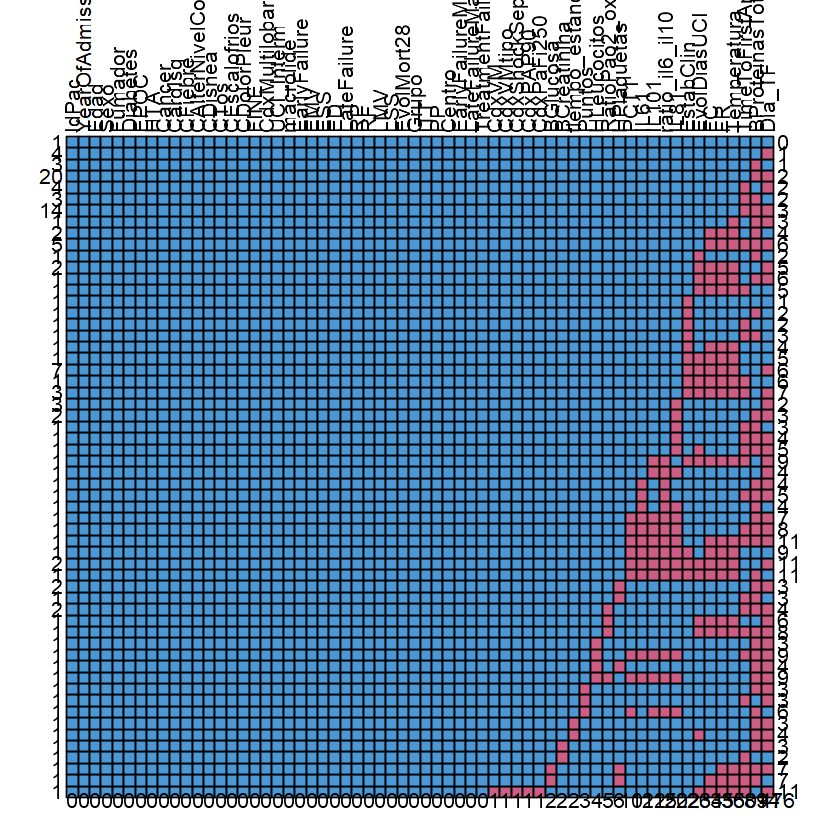

In [7]:
md.pattern(data_dint, rotate.names = TRUE)

Let's suppose MAR

## Intention to treat

### Descriptive statistics

In [8]:
#Test normality of numerical variables
normality <- sapply(data_dint[!names(data_dint) %in% "IdPac"],seek_normality)
data.frame(variable = names(normality), normality = normality)

,variable,normality
,<chr>,<chr>
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA
CardIsq,CardIsq,NA


In [9]:
#Explicit modalities of categorical variables
data_dint_explcit<-data_dint %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_explcit, "Grupo")

Variable,Category,Overall_N_prop,0_N_prop,1_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 (6.7%),5 (8.5%),3 (4.9%)
YearOfAdmission,2005,24 (20%),13 (22%),11 (18%)
YearOfAdmission,2006,21 (17.5%),8 (13.6%),13 (21.3%)
YearOfAdmission,2007,17 (14.2%),7 (11.9%),10 (16.4%)
YearOfAdmission,2008,14 (11.7%),7 (11.9%),7 (11.5%)
YearOfAdmission,2009,9 (7.5%),6 (10.2%),3 (4.9%)
YearOfAdmission,2010,13 (10.8%),7 (11.9%),6 (9.8%)
YearOfAdmission,2011,12 (10%),5 (8.5%),7 (11.5%)
YearOfAdmission,2012,2 (1.7%),1 (1.7%),1 (1.6%)


In [10]:
# Summary of numerical variables 
summary_num_by_group(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,0_mean_SD,0_med_IQR,0_min_max,1_mean_SD,1_med_IQR,1_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Edad,65.2 (19.6),69.5 (53.0 - 81.0),19.0 - 96.0,66.1 (20.1),70.0 (54.5 - 81.0),19.0 - 96.0,64.5 (19.1),69.0 (53.0 - 81.0),24.0 - 89.0
Puntos,108.6 (36.4),110.0 (86.0 - 135.0),4.0 - 212.0,110.2 (34.6),111.0 (91.0 - 135.0),4.0 - 173.0,107.1 (38.2),109.0 (85.8 - 134.2),28.0 - 212.0
RatioPao2_oxygen,232.9 (78.7),238.1 (179.6 - 270.5),63.6 - 609.5,229.6 (82.9),228.6 (170.5 - 287.6),76.0 - 407.5,236.2 (74.9),239.0 (210.1 - 265.6),63.6 - 609.5
BGlucosa,149.5 (72.4),130.5 (106.0 - 167.2),50.0 - 548.0,150.8 (65.6),129.0 (107.0 - 180.0),50.0 - 394.8,148.3 (78.9),131.0 (106.0 - 159.0),64.0 - 548.0
BCreatinina,1.6 (0.9),1.3 (1.0 - 1.8),0.4 - 5.2,1.6 (1.0),1.3 (1.0 - 1.8),0.4 - 5.2,1.5 (0.9),1.3 (0.9 - 1.8),0.6 - 4.9
HPlaquetas,248.0 (131.7),214.5 (175.2 - 283.0),32.0 - 864.0,260.4 (150.8),217.0 (175.0 - 283.0),81.0 - 864.0,235.7 (109.3),214.0 (176.0 - 282.0),32.0 - 630.0
HLeucocitos,15.1 (10.7),13.4 (9.0 - 19.7),0.7 - 74.0,14.9 (9.0),14.4 (9.2 - 23.0),0.7 - 36.7,15.3 (12.2),12.6 (9.0 - 16.7),1.3 - 74.0
BProteinasTot,27.8 (24.8),8.2 (6.6 - 56.5),4.9 - 69.0,23.4 (23.0),7.5 (6.8 - 47.0),5.2 - 58.0,31.2 (26.1),19.6 (6.3 - 57.5),4.9 - 69.0
PCT1,6.3 (11.8),1.8 (0.5 - 7.2),0.0 - 86.3,6.7 (8.6),3.1 (0.8 - 9.5),0.1 - 37.4,6.0 (14.2),1.2 (0.4 - 4.4),0.0 - 86.3


### Comparison tests

In [11]:
compare_var_cat(data_dint[!names(data_dint) %in% "IdPac"],"Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.886,No significative difference
Sexo,Chi2,0.427,No significative difference
Fumador,Chi2,0.872,No significative difference
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
CFiebre,Chi2,0.346,No significative difference


In [12]:
#Double check for septic shock
contingency <- table(data_dint$CdxShockSept, data_dint$Grupo)
print(chisq.test(contingency)$p.value)
print(fisher.test(contingency)$p.value)
# if (pval < 0.1) "associated/significative difference" else "No significative difference"

[1] 0.1178949
[1] 0.08699988


Associated/significatve difference for the the fisher test

In [13]:
compare_var_num(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"


Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
Edad,Mann-Whitney,0.592,No significative difference
Puntos,Student,0.652,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.695,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.607,No significative difference
HPlaquetas,Mann-Whitney,0.792,No significative difference
HLeucocitos,Mann-Whitney,0.485,No significative difference
BProteinasTot,Mann-Whitney,0.542,No significative difference
PCT1,Mann-Whitney,0.040,associated/significative difference


In [14]:
#Compare proportions
compare_proportions(data_dint[!names(data_dint) %in% "IdPac"], c("TreatmentFailureMan"
                                ,"EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS"),
                                 "Grupo")

Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"


Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.02,17 (3–31)
EarlyFailureMan,0.95,0 (-10–11)
EMV,0.69,2 (-8–11)
ESS,0.62,2 (-5–9)
ED,0.97,0 (-6–7)
LateFailureMan,0.00,22 (11–33)
RP,0.01,14 (4–23)
RF,0.09,7 (-1–15)
LMV,0.16,5 (-2–12)


In [15]:
compare_medians(data_dint[!names(data_dint) %in% "IdPac"], c("tiempo_estancia","EstabClin"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,0.5,-2.5 – 3,0.8311
EstabClin,-1.0,-2 – 1,0.2769


In [16]:
group0 <- data_dint[data_dint[["Grupo"]] == 0 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint[data_dint[["Grupo"]] == 1 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
EvolDiasUCI,-1,-3 – 2,0.7017


Significative difference for procalcitonin, IL-10 and septic shock

### Impute missing values

In [17]:
#Prepare variables
## Treatment failure
data_dint$TreatmentFailureMan <- as.numeric(as.character(data_dint$TreatmentFailureMan))
data_dint$Dia_TF[is.na(data_dint$Dia_TF)] <- 5 #Censor at 5 days

##Length of stay in hospital
data_dint$StayHosp <- as.numeric(as.character(ifelse(is.na(data_dint$tiempo_estancia),0,1)))

##Time in ICU
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data$EvolDiasInterm[is.na(data$EvolDiasUCI)]
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data_dint$tiempo_estancia[is.na(data_dint$EvolDiasUCI)]
data_dint$EvolDiasUCI[data_dint$UCI_Interm==0] <- 0
data_dint$EvolDiasUCI_tronq<-data_dint$EvolDiasUCI
data_dint$EvolDiasUCI_tronq[data_dint$UCI_Interm==1]<-ifelse(data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]>28 | data_dint$EvolMort28[data_dint$UCI_Interm==1]==1,28,data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]) #truncate at 28 days
data_dint$UCI_event<- as.numeric(as.character(ifelse(is.na(data$EvolUCIFechaAlta) | is.na(data$EvolIntermFechaAlta),0,1)))

## Clinical stability
data_dint$EstabClin_event <- as.numeric(as.character(ifelse(is.na(data_dint$EstabClin),0,1)))
data_dint$EstabClin[is.na(data_dint$EstabClin)] <- data_dint$tiempo_estancia[is.na(data_dint$EstabClin)]

##Create new  variables
data_dint$comorbidity<-with(data_dint,as.factor(as.character(ifelse(Diabetes==1|EPOC==1 | HTA==1| Cancer==1|CardIsq==1 ,1,0))))
data_dint$severity_index <-as.factor(as.character(ifelse(as.numeric(data_dint$FINE)>3,1,0)))
data_dint$vf_days <-28 - data_dint$EvolDiasUCI_tronq

In [18]:
#summary of comorbidity
compare_var_cat(data_dint[,c("IdPac","Diabetes","EPOC","HTA","Cancer","CardIsq","comorbidity","Grupo")], "Grupo")

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
comorbidity,Chi2,0.446,No significative difference


In [19]:
compare_proportions(data_dint, c("comorbidity","severity_index","Diabetes","EPOC","HTA","Cancer","CardIsq"), "Grupo")

Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
comorbidity,0.34,9 (-9–26)
severity_index,0.47,6 (-10–22)
Diabetes,0.43,6 (-8–20)
EPOC,0.18,9 (-4–22)
HTA,0.60,5 (-13–22)
Cancer,0.10,9 (-2–19)
CardIsq,0.52,-4 (-18–9)


In [20]:
with(data_dint,table(comorbidity, Grupo))

           Grupo
comorbidity  0  1
          0 23 29
          1 36 32

In [21]:
with(data_dint,table(comorbidity, TreatmentFailureMan))

           TreatmentFailureMan
comorbidity  0  1
          0 42 10
          1 54 14

In [22]:
with(data_dint,table(severity_index, Grupo))

              Grupo
severity_index  0  1
             0 14 18
             1 45 43

In [23]:
with(data_dint,table(severity_index, TreatmentFailureMan))

              TreatmentFailureMan
severity_index  0  1
             0 30  2
             1 66 22

In [24]:
with(data_dint,table(comorbidity,TreatmentFailureMan, Grupo))

, , Grupo = 0

           TreatmentFailureMan
comorbidity  0  1
          0 17  6
          1 25 11

, , Grupo = 1

           TreatmentFailureMan
comorbidity  0  1
          0 25  4
          1 29  3


In [25]:
with(data_dint,table(severity_index,TreatmentFailureMan, Grupo))

, , Grupo = 0

              TreatmentFailureMan
severity_index  0  1
             0 14  0
             1 28 17

, , Grupo = 1

              TreatmentFailureMan
severity_index  0  1
             0 16  2
             1 38  5


In [26]:
# Save  dataframe as CSV
write.csv(data_dint, "data_dint.csv", row.names = FALSE)


In [27]:
#Imputation
vars_to_impute<-caracs_dint[caracs_dint$number_of_missing_values>0,"variable"]
print(caracs_dint[caracs_dint$number_of_missing_values>0,"variable"])

 [1] "Puntos"                   "CdxVM"                   
 [3] "CdxVMtipo"                "CdxShockSept"            
 [5] "CdxPAP90"                 "CdxPaFi250"              
 [7] "RatioPao2_oxygen"         "TimeToFirstAntibiotic_SS"
 [9] "BGlucosa"                 "BCreatinina"             
[11] "HPlaquetas"               "HLeucocitos"             
[13] "BProteinasTot"            "PCT1"                    
[15] "IL61"                     "IL81"                    
[17] "IL101"                    "Temperatura"             
[19] "FR"                       "FC"                      
[21] "tiempo_estancia"          "EvolDiasUCI"             
[23] "EstabClin"                "Dia_TF"                  
[25] "ratio_il6_il10"          


In [28]:
# List of all column names
all_vars <- names(data_dint[!names(data_dint) %in% "IdPac"])

# Create a method vector with empty strings
meth <- rep("", length(all_vars))
names(meth) <- all_vars

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101","CdxShockSept")] <- "pmm"

# Run mice with the method vector
imp <- mice(data_dint[!names(data_dint) %in% "IdPac"], m = 5, method = meth, seed = 123)


 iter imp variable
  1   1  CdxShockSept  PCT1  IL101
  1   2  CdxShockSept  PCT1  IL101
  1   3  CdxShockSept  PCT1  IL101
  1   4  CdxShockSept  PCT1  IL101
  1   5  CdxShockSept  PCT1  IL101
  2   1  CdxShockSept  PCT1  IL101
  2   2  CdxShockSept  PCT1  IL101
  2   3  CdxShockSept  PCT1  IL101
  2   4  CdxShockSept  PCT1  IL101
  2   5  CdxShockSept  PCT1  IL101
  3   1  CdxShockSept  PCT1  IL101
  3   2  CdxShockSept  PCT1  IL101
  3   3  CdxShockSept  PCT1  IL101
  3   4  CdxShockSept  PCT1  IL101
  3   5  CdxShockSept  PCT1  IL101
  4   1  CdxShockSept  PCT1  IL101
  4   2  CdxShockSept  PCT1  IL101
  4   3  CdxShockSept  PCT1  IL101
  4   4  CdxShockSept  PCT1  IL101
  4   5  CdxShockSept  PCT1  IL101
  5   1  CdxShockSept  PCT1  IL101
  5   2  CdxShockSept  PCT1  IL101
  5   3  CdxShockSept  PCT1  IL101
  5   4  CdxShockSept  PCT1  IL101
  5   5  CdxShockSept  PCT1  IL101


Warning message:
"Number of logged events: 5"


### Logistic regression

In [29]:
# Variables to explain
vars_to_explain <- c("TreatmentFailureMan")#,
                     #"EarlyFailureMan","EMV","ESS","ED",
                     #"LateFailureMan","RP","RF","LMV","LSS","EvolMort28")

In [30]:
#initialize model
model_logit=logit(imp,vars_to_explain)
#Fitting model
main_var<-"Grupo"
other_variables<-c("IL101","PCT1","CdxShockSept","Centro","YearOfAdmission")
model_logit$fit_logit(main_var=main_var)

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan,0.32 (0.12 - 0.85),0.02294143


In [31]:
model_logit$fit_logit(main_var="comorbidity")

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan,1.09 (0.44 - 2.72),0.8541863


In [32]:
model_logit$fit_logit(main_var="severity_index")

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan,5 (1.09 - 23.01),0.0389524


In [33]:
model_logit$fit_logit(main_var=main_var, interraction_terms = c("comorbidity"))

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan x Grupo1,0.45 (0.11 - 1.88),0.2728315
TreatmentFailureMan x comorbidity1,1.25 (0.38 - 4.07),0.7125835
TreatmentFailureMan x Grupo1:comorbidity1,0.52 (0.07 - 3.81),0.5157165


In [34]:
model_logit$fit_logit(main_var=main_var, interraction_terms = c("severity_index"))

Variable_to_explain,OR_CI,p_value
<chr>,<chr>,<dbl>
TreatmentFailureMan x Grupo1,14456099.31 (0 - Inf),0.9924707
TreatmentFailureMan x severity_index1,70215339.49 (0 - Inf),0.9917490
TreatmentFailureMan x Grupo1:severity_index1,0 (0 - Inf),0.9917724


At level 5%, Grupo and Severity index are significantly correlated to treatment failure:
- The treatment significiatively decreases the chances of treatment failure 68% when the treatment is the only covariate introduced in the model . However, when adding comorbidity as second covariate and interraction between treatment and comorbidity, we fail at level 5% to find an effect of treatment and comorbidity (maybe because we fail to show that comorbidity is significantly correlated to treatment failure at 5% level); and the effect of the treatment does not seem to change accoding to whether or not the patient has a preexisting comorbid condition. The latter results should be taken with caution considering the small sample size. 
- Having a severity index >3 increseases the chances of treatment failure by 400% but this results are not reliable because of the very small number of patients in some categories of the contigency table (ex: no patient in the placebo group with severity <=3 have treatment failure so there is a quasi-complete separation). This may also explain the very high odds ratio with the model where the severity index is added as interraction term, even if none of the covariates are significant at 5% level.


In [35]:
#Model performances
# model_logit$performance_logit(main_var=main_var, other_variables=other_variables)#,interraction_terms = c("comorbidity"))

Let's consider:
- X: random variable representing the treatment group (0 for placebo)
- Y: random variable representing the treatment failure (1 for failure)
- $ W \in \mathbb{R}^p $: a vector of covariates (terms interracting with the main covariate X)

$Y=y \mid X=x, W=w \sim \text{B}(p(x,w))$, $x,y \in \{0,1\}, w \in \mathbb{R}^p$
where $p(x)= P(Y=y/X=x, W=w) = \frac{(exp[\beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j)])^y}{1+exp[\beta_0 + \beta_1x + \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j)]} \cdot \mathbf{1}_{x,y \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{N}^p} $

We consider a sample ${\{(Y_1, X_1, W_1), \ldots, (Y_n, X_n,W_n)\}}$ drawn from ${(Y, X, W)}$.\

The likelihood is given by:
$$
L(\boldsymbol{\theta}) = 
\prod_{i=1}^n  \Biggl[\frac{(exp[\beta_0 + \beta_1X_i+ \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}] ))^{Y_i} }{1+exp(\beta_0 + \beta_1X_i + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}))}\Biggr] \cdot \mathbf{1}_{X_i, Y_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p} 
$$
with $\theta =(\beta_0, \beta_1, \gamma_1,...,\gamma_p, \nu_1,...,\nu_p) $\
The log_likelihood is given by:

$$
l(\theta) = \sum_{i=1}^n Y_i\Biggl(\beta_0 + \beta_1X_i+  \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(Xi*W_{ij})\Biggr) -\sum_{i=1}^nlog\Biggl(1+exp(\beta_0 + \beta_1X_i + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(X_i*W_{ij}))\Biggr)

$$

In [36]:
ll_TF_interraction <- function(params, W=NULL){
  b0 <- params[1]
  b1 <- params[2]
  # Extract data
  X <- as.numeric(as.character(data_dint$Grupo))
  Y <- as.numeric(as.character(data_dint$TreatmentFailureMan))
  if (!is.null(W)){
    p <- length(W)  # number of covariates
    gamma  <- params[3:(2+p)]        # logistic main effects
    nu <- params[(3+p):(2+2*p)]  # logistic interactions
    # Extract data
    Wmat <- as.matrix(sapply(data_dint[, W, drop = FALSE], as.numeric))
    # Linear predictors
    logit_p <- b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% nu
  }else{
    # Linear predictors
    logit_p <- b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% nu
  }
  # Likelihood contributions
  ll <- Y*logit_p - log(1+exp(logit_p))
  return(sum(ll))}


In [37]:
table(data_dint$comorbidity)


 0  1 
52 68 

In [38]:
W <- c("comorbidity")
llTFint <- function(params) {
  ll_TF_interraction(params, W = W)
}
result_TFW <- maxLik(logLik = llTFint,start = rep(0, 2 + 2*length(W)))
summary(result_TFW)


--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 5 iterations
Return code 1: gradient close to zero (gradtol)
Log-Likelihood: -56.94976 
4  free parameters
Estimates:
     Estimate Std. error t value Pr(> t)
[1,]  -1.2619     1.0237  -1.233   0.218
[2,]  -0.1346     1.6129  -0.083   0.934
[3,]   0.2205     0.6013   0.367   0.714
[4,]  -0.6566     1.0138  -0.648   0.517
--------------------------------------------

In [39]:
beta0 <- coef(result_TFW)[1]
beta1 <- coef(result_TFW)[2]
gamma <- coef(result_TFW)[3]
nu <- coef(result_TFW)[4]

In [40]:
print(paste("Estimated Probaility of treatment failure for non comorbid in placebo group:",round((exp(beta0) / (1 + exp(beta0)))*100,2), "%"))
print(paste("Estimated Probability of treatment failure for non comorbid in treatment group:",round((exp(beta0+beta1) / (1 + exp(beta0+beta1)))*100,2), "%"))
print(paste("Estimated Probaility of treatment failure for comorbid in placebo group:",round((exp(beta0+gamma) / (1 + exp(beta0+gamma)))*100,2), "%"))
print(paste("Estimated Probability of treatment failure for comorbid in treatment group:",round((exp(beta0+beta1+gamma+nu) / (1 + exp(beta0+beta1+gamma+nu)))*100,2), "%"))

[1] "Estimated Probaility of treatment failure for non comorbid in placebo group: 22.06 %"
[1] "Estimated Probability of treatment failure for non comorbid in treatment group: 19.84 %"
[1] "Estimated Probaility of treatment failure for comorbid in placebo group: 26.09 %"
[1] "Estimated Probability of treatment failure for comorbid in treatment group: 13.79 %"


In [41]:
print(paste("True Probability of treatment failure for non comorbid  in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/20)*100,2), "%"))
print(paste("True Probability of treatment failure for non comorbid  in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/26)*100,2), "%"))
print(paste("True probability of treatment failure for comorbid  in placebo group:", 
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/39)*100,2), "%"))
print(paste("True of probability treatment failure for comorbid  in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/35)*100,2), "%"))

[1] "True Probability of treatment failure for non comorbid  in placebo group: 30 %"
[1] "True Probability of treatment failure for non comorbid  in treatment group: 15.38 %"
[1] "True probability of treatment failure for comorbid  in placebo group: 28.21 %"
[1] "True of probability treatment failure for comorbid  in treatment group: 8.57 %"


In [42]:
print(paste("Estimated odds of treatment failure for non comorbid in placebo group:",round((exp(beta0)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for non comorbid in treatment group:",round((exp(beta1)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for  comorbid in placebo group:",round((exp(gamma)-1)*100,2), "%"))
print(paste("Estimated odds of treatment failure for  comorbid in treatment group:",round((exp(nu)-1)*100,2), "%"))

[1] "Estimated odds of treatment failure for non comorbid in placebo group: -71.69 %"
[1] "Estimated odds of treatment failure for non comorbid in treatment group: -12.59 %"
[1] "Estimated odds of treatment failure for  comorbid in placebo group: 24.67 %"
[1] "Estimated odds of treatment failure for  comorbid in treatment group: -48.14 %"


In [43]:
print(paste("True odds of treatment failure for non comorbid in placebo group:",
round(((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True odds of treatment failure for non comorbid in treatment group:",
round(((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==0 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True odds of treatment failure for  comorbid in placebo group:", 
round(((nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==0 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))
print(paste("True of odds treatment failure for  comorbid in treatment group:",
round(((nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==1,])/nrow(data_dint[data_dint$Grupo==1 & data_dint$comorbidity==1 & data_dint$TreatmentFailureMan==0,]))-1)*100,2), "%"))

[1] "True odds of treatment failure for non comorbid in placebo group: -64.71 %"


[1] "True odds of treatment failure for non comorbid in treatment group: -84 %"
[1] "True odds of treatment failure for  comorbid in placebo group: -56 %"
[1] "True of odds treatment failure for  comorbid in treatment group: -89.66 %"


Let's suppose the model is regular:
$$
\text{Let's consider } z= \beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_{j} + \sum_{j=1}^p \nu_j(x*w_{j})\\
\text{The log-likelihood is:}\\
l(\theta) = \sum_{i=1}^n Y_iZ_i -\sum_{i=1}^nlog\Biggl(1+e^{Z_i}\Biggr) \text{ for all } X_i \in \{0,1\}, W_i \in \mathbb{N}^p
$$
**The gradient is:**
$$
\Delta l(\theta) = \begin{pmatrix}
\partial l(\theta)/ \partial \beta_0 \\
\partial l(\theta)/ \partial \beta_1 \\
\partial l(\theta)/ \partial \gamma_1 \\
.\\
.\\
.\\
\partial l(\theta)/ \partial \gamma_p \\
\partial l(\theta)/ \partial \nu_1
.\\
.\\
.\\
\partial l(\theta)/ \partial \nu_p
\end{pmatrix}
 =
\begin{pmatrix}
\sum_{i=1}^n (Y_i - \frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - X_i\frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - W{i1}\frac{e^{Z_i}}{1+e^{Z_i}})\\
.\\
.\\
.\\
\sum_{i=1}^n (Y_i - W{ip}\frac{e^{Z_i}}{1+e^{Z_i}})\\
\sum_{i=1}^n (Y_i - X_iW{i1}\frac{e^{Z_i}}{1+e^{Z_i}})
.\\
.\\
.\\
\sum_{i=1}^n (Y_i - X_iW{ip}\frac{e^{Z_i}}{1+e^{Z_i}})
\end{pmatrix}
$$
We note: $\pi_i=\frac{e^{Z_i}}{1+e^{Z_i}}  $, we have:
$$
\begin{cases}
\partial l(\theta)/ \partial \beta_0=\sum_{i=1}^n (Y_i - \pi_i)\\
\partial l(\theta)/ \partial \beta_1=\sum_{i=1}^n (Y_i - X_i\pi_i)\\
\partial l(\theta)/ \partial \gamma_j=\sum_{i=1}^n (Y_i - W_{ij}\pi_i)\\
\partial l(\theta)/ \partial \nu_j=\sum_{i=1}^n (Y_i - X_iW_{ij}\pi_i)\\
\end{cases}
$$
**The Hessian matrix:**\
We have:
$$
\begin{pmatrix}
\frac{\partial^2 l(\theta)}{\partial \beta_0^2} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \beta_1^2} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \gamma_j^2} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \nu_j^2} \\
\end{pmatrix}
=
-
\begin{pmatrix}
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \beta_0} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \beta_0} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \beta_1} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \beta_1} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \gamma_j} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \gamma_j} \\
\sum_{i=1}^n \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n X_i \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n W_{ij} \frac{\partial \pi_i}{\partial \nu_j} & \sum_{i=1}^n X_i W_{ij} \frac{\partial \pi_i}{\partial \nu_j} \\
\end{pmatrix}
$$
$$
\begin{cases}
\partial \pi_i/ \partial \beta_0=\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \beta_1=X_i\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \gamma_j=W_{ij}\pi_i(1-\pi_i)\\
\partial \pi_i/ \partial \nu_j=X_iW_{ij}\pi_i(1-\pi_i)\\
\end{cases}
$$
So with $\Pi_i=\pi_i(1-\pi_i)$:
$$
\begin{pmatrix}
\frac{\partial^2 l(\theta)}{\partial \beta_0^2} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_0 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \beta_1^2} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \beta_1 \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \gamma_j^2} & \frac{\partial^2 l(\theta)}{\partial \gamma_j \partial \nu_j} \\
\frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_0} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \beta_1} & \frac{\partial^2 l(\theta)}{\partial \nu_j \partial \gamma_j} & \frac{\partial^2 l(\theta)}{\partial \nu_j^2} \\
\end{pmatrix}
=
-
\begin{pmatrix}
\sum_{i=1}^n \Pi_i & \sum_{i=1}^n \Pi_iX_i  & \sum_{i=1}^n \Pi_iW_{ij} & \sum_{i=1}^n \Pi_iX_i W_{ij} \\
\sum_{i=1}^n \Pi_iX_i & \sum_{i=1}^n \Pi_iX_i^2  & \sum_{i=1}^n \Pi_iX_iW_{ij} & \sum_{i=1}^n \Pi_iX_i^2 W_{ij} \\\\
\sum_{i=1}^n \Pi_iW_{ij} & \sum_{i=1}^n \Pi_iX_iW_{ij}  & \sum_{i=1}^n \Pi_iW_{ij}^2 & \sum_{i=1}^n \Pi_iX_i W_{ij}^2 \\ \\
\sum_{i=1}^n \Pi_iX_i W_{ij} & \sum_{i=1}^n \Pi_iX_i^2 W_{ij}  & \sum_{i=1}^n \Pi_iX_i W_{ij}^2 & \sum_{i=1}^n \Pi_iX_i^2 W_{ij}^2 \\ \\
\end{pmatrix}
$$

The hessian matrix is :	
$$
H(\theta) = 
-\begin{pmatrix}
\sum_{i=1}^n \Pi_i & \sum_{i=1}^n \Pi_iX_i  & \sum_{i=1}^n \Pi_iW_{i1} & \cdots & \sum_{i=1}^n \Pi_iW_{ip} & \sum_{i=1}^n \Pi_iX_i W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i W_{ip}  \\
\sum_{i=1}^n \Pi_iX_i & \sum_{i=1}^n \Pi_iX_i^2  & \sum_{i=1}^n \Pi_iX_iW_{i1}& \cdots & \sum_{i=1}^n \Pi_iX_iW_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{ip} \\
\sum_{i=1}^n \Pi_iW_{i1} & \sum_{i=1}^n \Pi_iX_iW_{i1}  & \sum_{i=1}^n \Pi_iW_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iW_{i1}W_{ip} & \sum_{i=1}^n \Pi_iX_i W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i W_{i1}W_{ip}  \\ 
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots\\
\sum_{i=1}^n \Pi_iW_{ip} & \sum_{i=1}^n \Pi_iX_iW_{ip}  & \sum_{i=1}^n \Pi_iW_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iW_{ip}^2 & \sum_{i=1}^n \Pi_iX_i W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_iW_{ip}^2 \\ 
\sum_{i=1}^n \Pi_iX_i W_{i1} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}  & \sum_{i=1}^n \Pi_iX_i W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i W_{i1}W_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}^2 & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{i1}W_{ip} \\ 
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots\\
\sum_{i=1}^n \Pi_iX_i W_{ip} & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}  & \sum_{i=1}^n \Pi_iX_i W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i W_{ip}^2 & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}W_{i1} & \cdots & \sum_{i=1}^n \Pi_iX_i^2 W_{ip}^2 \\ 
\end{pmatrix}
$$
The fisher information is: $I(\theta) = -\mathbb{E}(H(\theta))$\

In a regular model, we can  construct asymptotic confidence intervals for $\theta$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{\theta}_n$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\theta_n} - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, I(\theta)^{-1}\right)
$$

Hence, if we consider I continuous, an asymptotic confidence interval of level $1 - \alpha$ is given by:

$$
IC_{1-\alpha}(\theta)=
\left[
\hat{\theta_n} - z_{1 - \alpha/2} \cdot \sqrt{\frac{I(\hat{\theta_n})^{-1}}{n}}, \;
\hat{\theta_n} + z_{1 - \alpha/2} \cdot \sqrt{\frac{I(\hat{\theta_n})^{-1}}{n}}
\right]
$$
$$
IC_{1-\alpha}(\theta_j)=
\left[
\hat{\theta_n}_j - z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}, \;
\hat{\theta_n}_j + z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}
\right]
$$

where $z_{1 - \alpha/2}$ is the $(1 - \alpha/2)$ quantile of the standard normal distribution, and $I(\hat{\theta})$ is the Fisher information evaluated at $\hat{\theta}$.\
Confidence interval for odds ratio:
$$
IC_{1-\alpha}(OR_{\theta_j}) \approx
\left[
e^{\hat{\theta_n}_j - z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}}, \;
e^{\hat{\theta_n}_j + z_{1 - \alpha/2} \cdot \sqrt{\frac{(I(\hat{\theta_n})^{-1})_{jj}}{n}}}

\right]
$$

Confidence interval for odds ration using delta method:

Let g be: $g : x \rightarrow e^x$, g is $C^\infty$ in $\mathbb{R}$ and 
$$
g(\theta)=\begin{pmatrix}
e^\beta_0 \\
e^\beta_1 \\
e^\gamma_1 \\
.\\
.\\
.\\
e^\gamma_p \\
e^\nu_1
.\\
.\\
.\\
e^\nu_p
\end{pmatrix}
$$
The jacobian is $\Delta g(\theta) =diag(e^{\beta_0},e^{\beta_1},e^{\gamma_1},...,e^{\gamma_p},e^{\nu_1},...,e^{\nu_p})$

We know that:
$$
\sqrt{n}(\hat{\theta_n} - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, I(\theta)^{-1}\right)
$$
So by application of the Delta method, we have:
$$
\sqrt{n}(e^{\hat{\theta_n}} - e^{\theta)} \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \Delta g(\theta) I(\theta)^{-1} \Delta g(\theta)'\right)
$$
with $OR(\theta)=e^\theta$. So:

$$
IC_{1-\alpha}(OR_{\theta_j}) =
\left[
e^{\hat{\theta_n}_j} \pm z_{1 - \alpha/2} \cdot \sqrt{\frac{(\Delta g(\hat{\theta_n})I(\hat{\theta_n})^{-1}\Delta g(\hat{\theta_n})')_{jj}}{n}}
\right]
$$


In [44]:
# 1) Redefine log_likelihood:
ll_raw <- function(beta0, beta1,gamma,nu,W ) {
  X <- as.numeric(as.character(data_dint$Grupo))
  Y <- as.numeric(as.character(data_dint$TreatmentFailureMan))
  Wmat <- as.matrix(sapply(data_dint[, W, drop = FALSE], as.numeric))
  logit_p <- beta0 + beta1*X + Wmat %*% gamma + (X*Wmat) %*% nu

  
  # Likelihood contributions
  ll <- Y*logit_p - log(1+exp(logit_p))
  return(sum(ll))
}

ll <- function(p) {
  beta0 <- p[1]
  beta1 <- p[2]
  k <- length(W)
  gamma  <- p[3:(2+k)]   
  nu <- p[(3+k):(2+2*k)]
  ll_raw(beta0, beta1,gamma,nu,W)
}

# 2) Calculate Hessian
W<-c("comorbidity")
p_hat <- c(beta0, beta1,gamma,nu)

info_fisher <- -hessian(ll, p_hat)
print(info_fisher)


          [,1]     [,2]      [,3]      [,4]
[1,] 18.240697 6.167026 28.598336  8.885776
[2,]  6.167026 6.167027  8.885776  8.885776
[3,] 28.598336 8.885776 49.313614 14.323276
[4,]  8.885776 8.885776 14.323276 14.323277


In [45]:
IC_beta0=c(beta0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]), beta0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[1,1]))
IC_beta1=c(beta1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]), beta1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[2,2]))
IC_gamma=c(gamma - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]), gamma+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[3,3]))
IC_nu=c(nu - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]), nu+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/120*info_fisher[4,4]))
IC_nu

[1] -1.31276183 -0.08830144

In [46]:
# If we consider: $logit P(Y\mid X=x, W=w)= \beta_0 + \beta_1x+ \sum_{j=1}^p \gamma_j w_{j} + \sum_{j=1}^p \nu_j(x*w_{j})$\
# The marginal effect of the treatment on this value is:
# $$ 
# l = \frac{dlogit P(Y\mid X=x, W=w)}{dx}= \beta_1 + \sum_{j=1}^p \nu_j w_j
# $$
# A confidence interval for $\hat{l}$ is: $[\hat(l) \pm z_{1-\frac{\alpha}{2}}\sqrt(\hat{var}(\hat{l}))]$ with\
# $\hat{var}(\hat{l})=var(\hat{\beta_1} + \sum_{j=1}^p \hat{\nu_j} w_j) \mathrm{Var}(l) = \mathrm{Var}(\beta_1) + \sum_{j=1}^{p} w_j^2 \, \mathrm{Var}(\nu_j) + 2 \sum_{j=1}^{p} w_j \, \mathrm{Cov}(\beta_1, \nu_j) + 2 \sum_{j=1}^{p-1} \sum_{k=j+1}^{p} w_j w_k \, \mathrm{Cov}(\nu_j, \nu_k)
# $

Now we model the absolute difference of probability of treatment failure in placebo and treatment group:\
Let $X_0$ and $X_1$ be 2 random variables s.t:
$$
X_0=
\begin{cases}
1, & \text{if patient in placebo group and observed a treatment failure}\\
0, & \text{otherwise}
\end{cases}

X_1=
\begin{cases}
1, & \text{if patient in treament group and observed a treatment failure}\\
0, & \text{otherwise}
\end{cases}
$$
$X_0 \sim B(p_0)$ and $X_1 \sim B(p_1)$ with:
- $p_0$= probability of treatment failure in placebo group
- $p_1$= probability of treatment failure in treatment group

Let's consider 2 i.i.d samples $(X_{0_1},...,X_{0_{n_0}})$ and  $(X_{1_1},...,X_{1_{n_1}})$ drwn respectively from $X_0$ and $X_1$. We have:
- $\mathbb{E}(X_0)=p_0 <\infty$ and $\mathbb{E}(X_1)=p_1 <\infty$
- $\mathbb{V}(X_0)=p_0(1-p_0) > 0$ and $\mathbb{V}(X_1)=p_1(1-p_1) >0$
Central Limit theorem:
$$
\sqrt{n_0}(\bar{X}_{0_n} - p_0) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, p_0(1-p_0)\right)
$$
$$
\sqrt{n_1}(\bar{X}_{1_n} - p_1) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, p_1(1-p_1)\right)
$$
with $\bar{X}_{0_n}= \frac{1}{n_0}\sum_{i=1}^{n_0} X_{0_i}$ and $\bar{X}_{1_n}= \frac{1}{n_1}\sum_{i=1}^{n_1} X_{1_i}$. Since $X_0$ and $X_1$ are independent, we have:
$$
[(\bar{X}_{0_n}-\bar{X}_{1_n}) - (p_0-p_1)] \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{n_1p_0(1-p_0)+n_0p_1(1-p_1)}{n_0n_1}\right)
$$
Confidence interval of absolute difference of probabilities:
$$
IC_{1-\alpha}(p_0-p_1) = \Biggl[(\bar{X}_{0_n}-\bar{X}_{1_n}) \pm z_{1-\frac{\alpha}{2}} \sqrt{\frac{n_1p_0(1-p_0)+n_0p_1(1-p_1)}{n_0n_1}}\Biggr]
$$
where $z_{1-\frac{\alpha}{2}}$ is the $(1-\frac{\alpha}{2})$ quantile of the standard normal distribution,

### Log-rank test and cox model

       chisq df     p
Grupo   3.24  1 0.072
GLOBAL  3.24  1 0.072


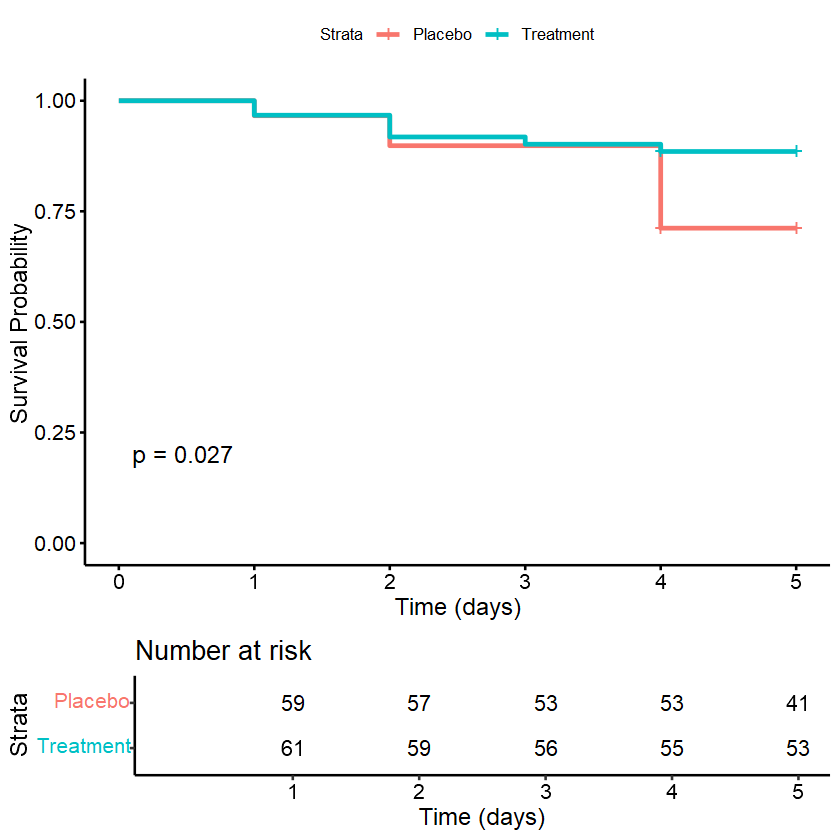

In [47]:
# Proportional hazard test for our variables of interest
surv_TF<-Surv(data_dint$Dia_TF, data_dint$TreatmentFailureMan) 
cox_model <- coxph(surv_TF~ Grupo, data= data_dint)

# Test proportional hazards assumption
ph_test <- cox.zph(cox_model)

# Print the results
print(ph_test)

#Log rank test
fit <- survfit(surv_TF ~ Grupo, data = data_dint)
ggsurvplot(fit, data = data_dint, pval = TRUE, conf.int = FALSE,
           risk.table = TRUE, legend.labs = c("Placebo", "Treatment"),
           xlab = "Time (days)", ylab = "Survival Probability")


In [48]:
#Model
vars_to_expl <- list(c("Dia_TF","TreatmentFailureMan"),
                    c("tiempo_estancia","StayHosp"),
                     c("EvolDiasUCI","UCI_event"),
                     c("EstabClin","EstabClin_event"))
cox(imp,vars_to_expl)$get_cox_results(main_var="Grupo", other_variables=other_variables)#, interraction_terms=c("comorbidity"))

Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  14 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  5 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, in

Time,Event,HR_CI_not_adjusted,p_value_1,HR_CI_adjusted,p_value_2,ph_test_p_value,ph_test_verdict
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Dia_TF,TreatmentFailureMan x 1,0.38 (0.15 - 0.96),0.04167194,0.32 (0.09 - 1.15),0.07214309,0.072,PH assumption met
tiempo_estancia,StayHosp x 1,1.01 (0.7 - 1.46),0.96566695,1 (0.66 - 1.52),0.98171935,0.718,PH assumption met
EvolDiasUCI,UCI_event x 1,1.23 (0.6 - 2.52),0.55726073,0.96 (0.34 - 2.76),0.94065874,0.258,PH assumption met
EstabClin,EstabClin_event x 1,1.01 (0.68 - 1.52),0.95460566,1.11 (0.7 - 1.77),0.64312436,0.181,PH assumption met


### Count data : ventilation-free days

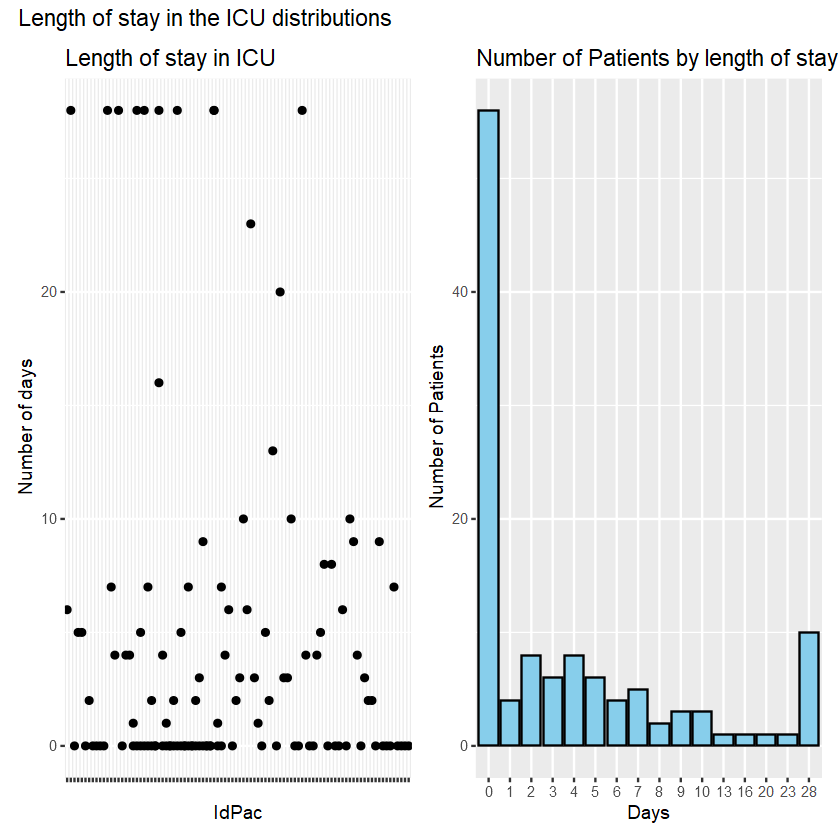

In [49]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI_tronq), ], aes(x = factor(IdPac), y = EvolDiasUCI_tronq)) +
  geom_point() +
  labs(title = "Length of stay in ICU", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI_tronq), ], aes(x = factor(EvolDiasUCI_tronq))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by length of stay in the ICU",
       x = "Days",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "Length of stay in the ICU distributions")


In [50]:
#Evaluate dispersion
print(mean(data_dint$EvolDiasUCI_tronq, na.rm=TRUE))
print(var(data_dint$EvolDiasUCI_tronq, na.rm=TRUE))

[1] 4.907563
[1] 65.72867


In [122]:
summary(pool(with(imp,glm(EvolDiasUCI_tronq ~ Grupo, family = poisson))))
completed_datasets <- complete(imp, action = "all")
overdisp_test <- lapply(completed_datasets, function(dat) {
  m <- glm(EvolDiasUCI_tronq ~ Grupo, family = poisson, data = dat)
  chi2 <- sum(residuals(m, type = "pearson")^2)
  print(chi2)
  df <- df.residual(m)
  print(df)  
})
qchisq(0.95, 115)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.8057849,0.05277797,34.21475,115.0385,3.922793e-62
Grupo1,-0.4840291,0.08502911,-5.69251,115.0385,9.722145e-08


[1] 1513.56
[1] 117
[1] 1513.56
[1] 117
[1] 1513.56
[1] 117
[1] 1513.56
[1] 117
[1] 1513.56
[1] 117


[1] 141.0297

Here: $\chi^2 = 1513.56 > \chi^2_{\text{0.05}, \text{115}} = 141.030$ ,so we reject the null hypothesis of equidispersion.

In [123]:
print(paste("Average stay of placebo group:", exp(1.8057849)))
print(paste("Average stay of treatment group:", exp(1.8057849-0.4840291)))

[1] "Average stay of placebo group: 6.08474549143833"
[1] "Average stay of treatment group: 3.74999985006631"


#### Frequentist approach : likelihood maximum

##### Number of days in the ICU

Let's consider:
- X: the random variable representing the treatment group (0 for placebo) $X \in \{0,1\}$
- Y: the random variable to explain, representing the number of days spent in the ICU , $Y \in \{0,28\}$
- Z the variable which indicates if the patient died, $ Z \in \{0,1\}$.
X,Y and Z are not independent.

**Conditional probability formula**
$$
\begin{cases}
P(Y,Z \mid X) = \dfrac{P(Y,Z,X)}{P(X)} \\
P(Y \mid Z,X) = \dfrac{P(Y,Z,X)}{P(Z,X)} \\
P(Z,X) = P(Z \mid X) \, P(X)
\end{cases}
$$
So $P(Y,Z,X)=P(Y/Z,X)P(Z/X)P(X)$. Therefore:\
$$
\boxed{P(Y,Z \mid X) = P(Y \mid Z,X)\, P(Z \mid X)}
$$

**Distribution of number of days in the ICU**
We model the number of days in the ICU (Y) considering treatment group (X) and death(Z). In particular, if the patient died (Z=1), the number of days is of 28 days (Y=28). So we have:
$$
\begin{cases}
Y \mid X=x, Z = 0 \sim \text{BN}(\mu_{x},\theta), x \in \{0,1\} \\
P(Y=28/Z=1, X)=P(Z=1/X)=\left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right) \cdot \mathbf{1}_{x \in \{0,1\}}
\end{cases}
$$
with:
- $\mu_{x} = \exp(\beta_0 + \beta_1 x)$ the average number of days spent in the ICU, which is considered dependent on the treatment
- P(Z=1/X), the probability of dying considering the treatment, modelled using a logistic regression\
So:
$$
\begin{cases}
P(Y, Z=0\mid X=x)= P(Y \mid X=x, Z=0)P(Z=0/X=x)\\
P(Y=28,Z=1\mid X=x)=\mathbf{1}_{Y=28}P(Z=1/X)
\end{cases}
$$
Finally:
$$
\boxed{
\begin{aligned}
f_{Y,Z \mid X}(y,z \mid x) =\ & \frac{\Gamma(y + \theta)}{\Gamma(\theta)\, y!}
\left( \frac{\theta}{\theta + \mu_x} \right)^{\theta}
\left( \frac{\mu_x}{\theta + \mu_x} \right)^y
\left( \frac{1}{1 + \exp(\alpha_0 + \alpha_1 x)} \right)
\cdot\ \mathbf{1}_{\mathbb{N}}(y)
\cdot \mathbf{1}_{\{\mu_x, \theta  > 0\}}
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=0} \\
& + \left( \frac{\exp(\alpha_0 + \alpha_1 x)}{1 + \exp(\alpha_0 + \alpha_1 x)} \right)
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=1}
\cdot \mathbf{1}_{y=28}
\end{aligned}
}
$$



We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\
The model is dominated by the counting measure $\delta$, and let $P_{\mu_{x,z},\theta}$ be the probability distribution associated with the model. Then, the density with respect to $\delta$ is given by:

$$
\frac{dP_{\mu_{x,z}, \theta}}{d\delta}(y) = f_{Y,Z \mid X}(y, z \mid x)
$$

a) The support of the density function does not depend on $\mu$ nor $\theta$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[^2$.

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}

\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} , & \text{for all i such that $Z_i$ =0} \\ 
\prod_{i=1}^n  \left(\frac{exp(\alpha_0 + \alpha_1X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{X_i \in \{0,1\}}& \text{for all i such that $Z_i$ =1 and $Y_i$=28}

\end{cases}
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i}) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1 and $Y_i$=28}

\end{cases}
$$

$$
\ell(\boldsymbol{\alpha, \beta}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\exp(\beta_0 + \beta_1 X_i)) + Y_i\exp(\beta_0 + \beta_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$

In [ ]:
X<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))
Y<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))

In [ ]:
ll_NB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    X1<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1]))
    Y0<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    mu <- exp(b0+b1*X0)
    theta<- mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE)^2/(var(data_dint$EvolDiasUCI_tronq, na.rm = TRUE)-mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE))
    ll_0<-sum(
      lgamma(Y0+theta)-
      lgamma(Y0+1)+
      theta* log(theta)-
      lgamma(theta)-
      (theta + Y0)*log(theta+mu)+
      Y0*log(mu)-
      log(1 + exp(a0+a1*X0))
    )
    ll_1<-sum(
      a0+a1*X1-
      log(1 + exp(a0+a1*X1))
    )
  ll <- ifelse(Z == 0, ll_0, ll_1) 
  return(ll)
}
Z<-as.numeric(as.character(data_dint$EvolMort28[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))

In [ ]:
#negative binomial to estimate los in ICU
nb_model <- with(
  imp,
  glm.nb(EvolDiasUCI_tronq ~ Grupo + EvolMort28, subset = UCI_Interm == 1)
)
summary(pool(nb_model))

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.53492137,0.1936029,7.9281926,84.05899,8.409724e-12
Grupo1,-0.08996325,0.2706619,-0.3323823,84.05899,7.404280e-01
EvolMort281,1.82050411,0.4486811,4.0574565,84.05899,1.105896e-04


In [ ]:
result_NB_death <- maxLik(logLik = ll_NB_death, start = c(0,0,0,0))
summary(result_NB_death)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 8 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -17277.85 
4  free parameters
Estimates:
     Estimate Std. error t value  Pr(> t)    
[1,] -4.23669    0.14141 -29.959  < 2e-16 ***
[2,] -1.07425    0.28291  -3.797 0.000146 ***
[3,]  1.53870    0.02873  53.550  < 2e-16 ***
[4,] -0.09768    0.04102  -2.381 0.017264 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
a0 <- coef(result_NB_death)[1]
a1 <- coef(result_NB_death)[2]
b0 <- coef(result_NB_death)[3]
b1 <- coef(result_NB_death)[4]

In [ ]:
print(paste("Estimated Probaility of death in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probability of death in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Number of days in ICU for non dead patients in placebo group:", exp(b0)))
print(paste("Estimated Number of days in ICU for non dead patients in treatment group:", exp(b0+b1)))

[1] "Estimated Probaility of death in placebo group: 1.42 %"
[1] "Estimated Probability of death in treatment group: 0.49 %"
[1] "Estimated Number of days in ICU for non dead patients in placebo group: 4.65853539713569"
[1] "Estimated Number of days in ICU for non dead patients in treatment group: 4.22500371966805"


In [ ]:
print(paste("True Probability of death in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Probability of death in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Number of days in ICU for non dead patients in placebo group:", 
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))
print(paste("True Number of days in ICU for non dead patients in treatment group:",
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))

[1] "True Probability of death in placebo group: 6.67 %"
[1] "True Probability of death in treatment group: 2.22 %"
[1] "True Number of days in ICU for non dead patients in placebo group: 4.65853658536585"
[1] "True Number of days in ICU for non dead patients in treatment group: 4.225"


The results match for number of days

In a regular model, we can  construct asymptotic confidence intervals for $\theta$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{\theta}_n$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{1}{I(\theta)}\right)
$$

Hence, an asymptotic confidence interval of level $1 - \alpha$ is given by:

$$
\left[
\hat{\theta}_n - z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}, \;
\hat{\theta}_n + z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}
\right]
$$

where $z_{1 - \alpha/2}$ is the $(1 - \alpha/2)$ quantile of the standard normal distribution, and $I(\hat{\theta}_n)$ is the Fisher information evaluated at $\hat{\theta}_n$.


In [ ]:
# 1) Redefine log_likelihood:
ll_raw <- function(alpha0, alpha1, beta0, beta1) {
  mu  <- exp(beta0 + beta1 * X)
  eta <- alpha0 + alpha1 * X
  
  # for Z=0
  idx0 <- which(Z == 0)
  theta<- mean(Y[idx0],na.rm=TRUE)^2/(var(Y[idx0], na.rm = TRUE)-mean(Y[idx0],na.rm=TRUE))
  term0 <- sum(
    lgamma(Y[idx0] + theta) - lgamma(theta) - lgamma(Y[idx0] + 1) +
    theta * log(theta / (theta + mu[idx0])) +
    Y[idx0] * log(mu[idx0] / (theta + mu[idx0])) -
    log(1 + exp(eta[idx0]))
  )
  
  # for Z=1
  idx1 <- which(Z == 1)
  term1 <- sum(
    eta[idx1] - log(1 + exp(eta[idx1]))
  )
  
  return(term0 + term1)
}

ll <- function(p) {
  alpha0 <- p[1]
  alpha1 <- p[2]
  beta0  <- p[3]
  beta1  <- p[4]
  ll_raw(alpha0, alpha1, beta0, beta1)
}

# 2) Calculate Hessian
p_hat <- c(a0, a1, b0, b1)

info_fisher <- -hessian(ll, p_hat)
print(info_fisher)


              [,1]          [,2]          [,3]          [,4]
[1,]  8.655128e-01  2.053342e-01  0.000000e+00 -4.768372e-07
[2,]  2.053342e-01  2.053337e-01 -9.536743e-07 -4.768372e-07
[3,]  0.000000e+00 -9.536743e-07  4.653295e+01  2.283207e+01
[4,] -4.768372e-07 -4.768372e-07  2.283207e+01  2.283207e+01


In [ ]:
IC_a0=c(a0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]), a0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]))
IC_a1=c(a1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]), a1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]))
IC_b0=c(b0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]), b0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]))
IC_b1=c(b1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]), b1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]))
IC_b1

[1] -0.9261545  0.7307926

Let's consider comorbidity then severity index as main covariates

In [ ]:
with(data_dint,table(EvolMort28,comorbidity,Grupo))

, , Grupo = 0

          comorbidity
EvolMort28  0  1
         0 22 28
         1  1  8

, , Grupo = 1

          comorbidity
EvolMort28  0  1
         0 27 28
         1  2  4


In [ ]:
with(data_dint,table(EvolMort28,severity_index,Grupo))

, , Grupo = 0

          severity_index
EvolMort28  0  1
         0 14 36
         1  0  9

, , Grupo = 1

          severity_index
EvolMort28  0  1
         0 18 37
         1  0  6


Let's add other covariates. We consider:
- X: the random variable representing the treatment group (0 for placebo) $X \in \{0,1\}$
- Y: the random variable to explain, representing the number of days spent in the ICU , $Y \in \{0,28\}$
- Z the variable which indicates if the patient died, $ Z \in \{0,1\}$.
X,Y and Z are not independent.
- $ W \in \mathbb{R}^p $: a vector of covariates (terms interracting with the main covariate X)

**Distribution of number of days in the ICU**
We model the number of days in the ICU (Y) considering treatment group (X), other covariates and death(Z). In particular, if the patient died (Z=1), the number of days is of 28 days (Y=28). So we have:
$$
\begin{cases}
Y \mid X=x, W=w, Z = 0 \sim \text{BN}(\mu_{x,w},\theta), x \in \{0,1\}, w \in \mathbb{N}^p  \\
P(Y/X=x, W=w, Z=1)=\mathbf{1}_{Y=28} P(Z=1/X=x,W=w)=\mathbf{1}_{y=28}\left(\frac{exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x*w_j)) }{1+ exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_jW_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))}\right) \cdot \mathbf{1}_{x \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{N}^p}
\end{cases}
$$
with:
- $\mu_{x,w} = \exp(\beta_0 + \beta_1 x + \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j))$ the average number of days spent in the ICU, which is considered dependent on the treatment
- P(Z=1/X,W), the probability of dying considering the treatment and covariates, modelled using a logistic regression

So :

$$
\boxed{
\begin{aligned}
f_{Y,Z \mid X,W}(y,z \mid x,w) =\ & \frac{\Gamma(y + \theta)}{\Gamma(\theta)\, y!}
\left( \frac{\theta}{\theta + \mu_{x,w}} \right)^{\theta}
\left( \frac{\mu_x}{\theta + \mu_{x,w}} \right)^y
\left( \frac{1}{1 + exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_jW_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))} \right)
\cdot\ \mathbf{1}_{\mathbb{N}}(y)
\cdot \mathbf{1}_{\{\mu_{x,w}, \theta  > 0\}}
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=0} \cdot \mathbf{1}_{w \in \mathbb{N}^p} \\
& + \left( \frac{exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))}{1 + exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))} \right)
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=1} \cdot \mathbf{1}_{w \in \mathbb{N}^p}\cdot \mathbf{1}_{y=28}
\end{aligned}
}
$$



We consider a sample ${\{(Y_1, X_1, Z_1, W_1), \ldots, (Y_n, X_n, Z_n,W_n)\}}$ drawn from ${(Y, X, Z, W)}$.\

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}

\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i,W_i}} \right)^{\theta} \left( \frac{\mu_{X_i,W_i}}{\theta + \mu_{X_i,W_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i,W_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p} , & \text{for all i such that $Z_i$ =0} \\ 
\prod_{i=1}^n  \left(\frac{ exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}{1+  exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}\right) \cdot \mathbf{1}_{X_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p}& \text{for all i such that $Z_i$ =1 and $Y_i$=28}

\end{cases}
$$

with  $\mu_{X_i,W_i} = \exp(\beta_0 + \beta_1 x + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(Xi*W_{ij}))$

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i, W_i}) + Y_i \log (\mu_{X_i,W_i}) - log(1 + exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})) - log(1 + exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$



In [ ]:
ll_NB_death_interraction <- function(params, W){
  p <- length(W)  # number of covariates
  
  a0 <- params[1]
  a1 <- params[2]
  b0 <- params[3]
  b1 <- params[4]
  
  eta  <- params[5:(4+p)]        # logistic main effects
  zeta <- params[(5+p):(4+2*p)]  # logistic interactions
  
  gamma <- params[(5+2*p):(4+3*p)]  # NB main effects
  delta <- params[(5+3*p):(4+4*p)]  # NB interactions
  
  # Extract data
  idx <- !is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1
  X <- as.numeric(as.character(data_dint$Grupo[idx]))
  Y <- as.numeric(as.character(data_dint$EvolDiasUCI_tronq[idx]))
  Z <- as.numeric(as.character(data_dint$EvolMort28[idx]))
  
  Wmat <- as.matrix(sapply(data_dint[idx,W ], as.numeric))
  
  # Linear predictors
  logit_p <- a0 + a1*X + Wmat %*% eta + (X*Wmat) %*% zeta
  mu      <- exp(b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% delta)
  
  # NB dispersion (method of moments estimate, but could make param)
  theta <- mean(Y,na.rm=TRUE)^2 / (var(Y,na.rm=TRUE)-mean(Y,na.rm=TRUE))
  
  # Likelihood contributions
  ll <- numeric(length(Y))
  
  # survivors
  surv <- which(Z==0)
  ll[surv] <- lgamma(Y[surv]+theta) -
              lgamma(Y[surv]+1) +
              theta*log(theta) -
              lgamma(theta) -
              (theta+Y[surv])*log(theta+mu[surv]) +
              Y[surv]*log(mu[surv]) -
              log(1+exp(logit_p[surv]))
  
  # deaths
  died <- which(Z==1)
  ll[died] <- logit_p[died] - log(1+exp(logit_p[died]))
  
  return(sum(ll))
}


In [ ]:
W <- c("comorbidity")
ll_fun <- function(params) {
  ll_NB_death_interraction(params, W = W)
}
result_NB_death_W <- maxLik(logLik = ll_fun,start = rep(0, 4 + 4*length(W)))
summary(result_NB_death_W)


--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 19 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -227.4942 
8  free parameters
Estimates:
     Estimate Std. error t value Pr(> t)
[1,] -24.7701        Inf       0       1
[2,]  52.0324        Inf       0       1
[3,]   0.7143        Inf       0       1
[4,]   1.0480        Inf       0       1
[5,]  11.7354        Inf       0       1
[6,] -41.3473        Inf       0       1
[7,]   0.5155        Inf       0       1
[8,]  -0.7373        Inf       0       1
--------------------------------------------

In [ ]:
#Death
a0 <- coef(result_NB_death_W)[1]
a1 <- coef(result_NB_death_W)[2]
eta <- coef(result_NB_death_W)[3]
zeta <- coef(result_NB_death_W)[4]
#ICU
b0 <- coef(result_NB_death_W)[5]
b1 <- coef(result_NB_death_W)[6]
gamma <- coef(result_NB_death_W)[7]
nu <- coef(result_NB_death_W)[8]

In [ ]:
print(paste("Estimated Probability of death for non comorbid in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probability of death for non comorbid in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Probability of death for  comorbid in placebo group:",round((exp(a0+eta) / (1 + exp(a0+eta)))*100,2), "%"))
print(paste("Estimated Probability of death for  comorbid in treatment group:",round((exp(a0+a1+eta+zeta) / (1 + exp(a0+a1+eta+zeta)))*100,2), "%"))
print(paste("Estimated Number of days in ICU for non dead non comorbid in placebo group:", exp(b0)))
print(paste("Estimated Number of days in ICU for non dead non comorbid in treatment group:", exp(b0+b1)))
print(paste("Estimated Number of days in ICU for non dead  comorbid in placebo group:", exp(b0+gamma)))
print(paste("Estimated Number of days in ICU for non dead comorbid in treatment group:", exp(b0+b1+gamma+nu)))

[1] "Estimated Probability of death for non comorbid in placebo group: 0 %"
[1] "Estimated Probability of death for non comorbid in treatment group: 100 %"
[1] "Estimated Probability of death for  comorbid in placebo group: 0 %"
[1] "Estimated Probability of death for  comorbid in treatment group: 100 %"
[1] "Estimated Number of days in ICU for non dead non comorbid in placebo group: 124915.116277307"
[1] "Estimated Number of days in ICU for non dead non comorbid in treatment group: 1.37941624402816e-13"
[1] "Estimated Number of days in ICU for non dead  comorbid in placebo group: 209161.367888178"
[1] "Estimated Number of days in ICU for non dead comorbid in treatment group: 1.10498851093698e-13"


In [ ]:

print(paste("True Probability of death for non comorbid in placebo group:",round((nrow(data_dint[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==0 & data_dint$Grupo==0  , ])/90)*100,2), "%"))
print(paste("True Probability of death for non comorbid in treatment group:",round((nrow(data_dint[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==0 & data_dint$Grupo==1 , ])/90)*100,2), "%"))
print(paste("True Probability of death for  comorbid in placebo group:",round((nrow(data_dint[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==1 & data_dint$Grupo==0  , ])/90)*100,2), "%"))
print(paste("True Probability of death for comorbid in treatment group:",round((nrow(data_dint[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==1 & data_dint$Grupo==1  , ])/90)*100,2), "%"))
print(paste("True Number of days in ICU for non dead non comorbid in placebo group:", mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==0 ], na.rm=TRUE)))
print(paste("True Number of days in ICU for non dead non comorbid in treatment group:", mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==0 ], na.rm=TRUE)))
print(paste("True Number of days in ICU for non dead comorbid in placebo group:", mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==1 ], na.rm=TRUE)))
print(paste("True Number of days in ICU for non dead comorbid in treatment group:", mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==1 ], na.rm=TRUE)))

[1] "True Probability of death for non comorbid in placebo group: 0 %"
[1] "True Probability of death for non comorbid in treatment group: 2.22 %"
[1] "True Probability of death for  comorbid in placebo group: 6.67 %"
[1] "True Probability of death for comorbid in treatment group: 0 %"
[1] "True Number of days in ICU for non dead non comorbid in placebo group: 3.42105263157895"
[1] "True Number of days in ICU for non dead non comorbid in treatment group: 4.66666666666667"
[1] "True Number of days in ICU for non dead comorbid in placebo group: 5.72727272727273"
[1] "True Number of days in ICU for non dead comorbid in treatment group: 3.73684210526316"


In [ ]:
with(data_dint[data_dint$UCI_Interm==1,],table(EvolMort28,comorbidity, Grupo))

, , Grupo = 0

          comorbidity
EvolMort28  0  1
         0 19 22
         1  0  6

, , Grupo = 1

          comorbidity
EvolMort28  0  1
         0 21 20
         1  2  0


##### Ventilation-free days

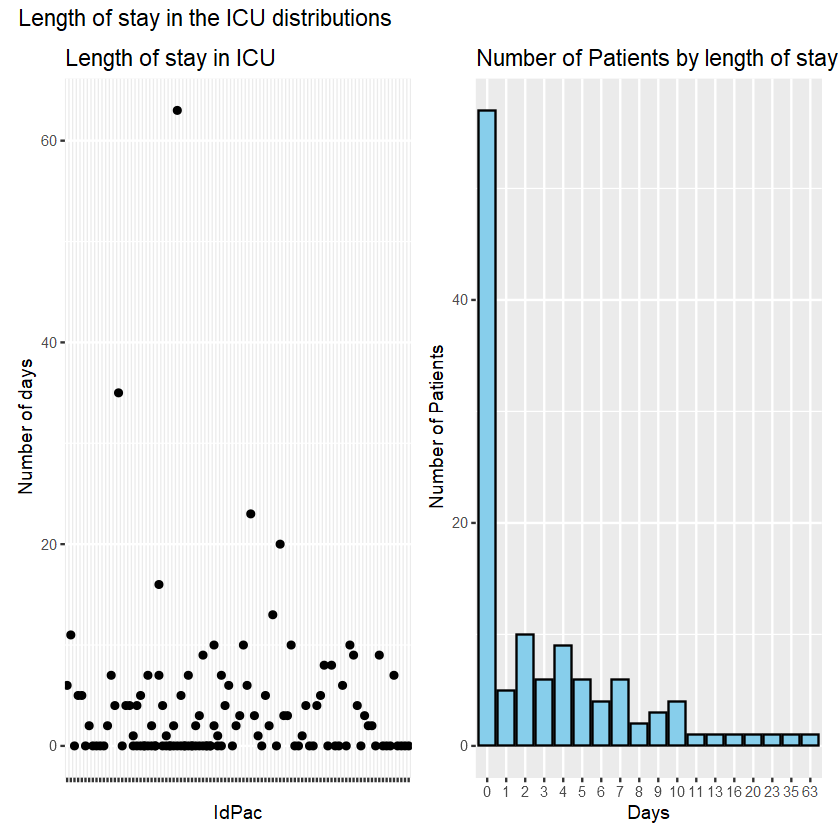

In [ ]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI), ], aes(x = factor(IdPac), y = EvolDiasUCI)) +
  geom_point() +
  labs(title = "Length of stay in ICU", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI), ], aes(x = factor(EvolDiasUCI))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by length of stay in the ICU",
       x = "Days",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "Length of stay in the ICU distributions")


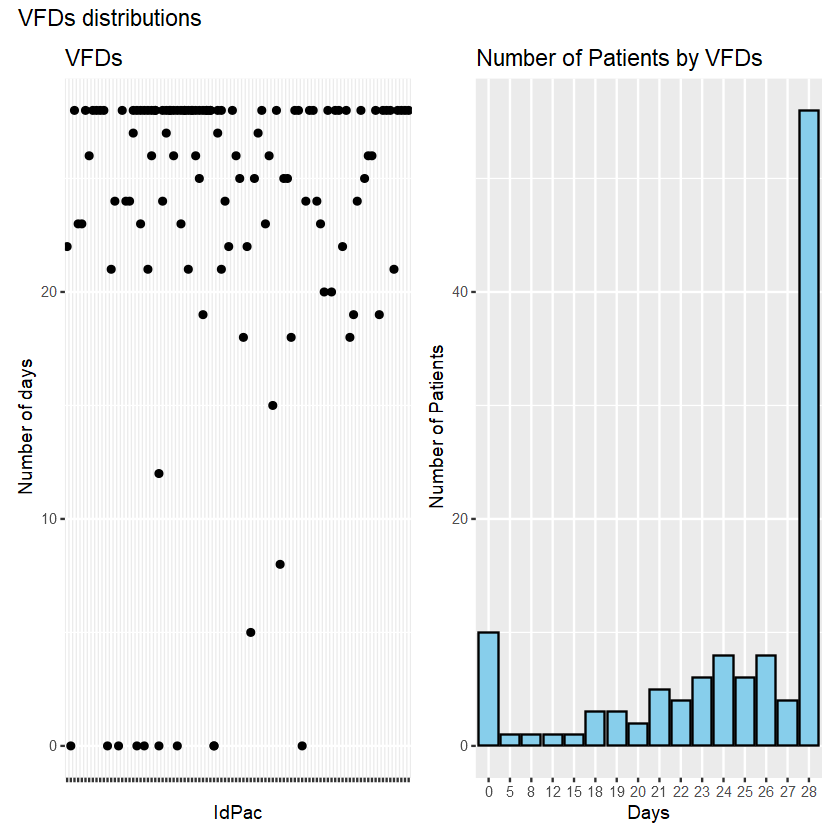

In [ ]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$vf_days), ], aes(x = factor(IdPac), y = vf_days)) +
  geom_point() +
  labs(title = "VFDs", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$vf_days), ], aes(x = factor(vf_days))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by VFDs",
       x = "Days",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "VFDs distributions")


In [ ]:
print(paste("mean: ",mean(data_dint$vf_days,na.rm=TRUE)))
print(paste("variance: ",var(data_dint$vf_days,na.rm=TRUE)))

[1] "mean:  23.0924369747899"
[1] "variance:  65.7286711294687"


In [121]:
summary(pool(with(imp,glm(vf_days ~ Grupo, family = poisson))))
completed_datasets <- complete(imp, action = "all")
overdisp_test <- lapply(completed_datasets, function(dat) {
  m <- glm(vf_days ~ Grupo, family = poisson, data = dat)
  chi2 <- sum(residuals(m, type = "pearson")^2)
  print(chi2)
  df <- df.residual(m)
  print(df)  
})
qchisq(0.95, 115)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.0871829,0.02780927,111.012715,115.0385,7.621376e-119
Grupo1,0.1012337,0.03821832,2.648826,115.0385,9.212057e-03


[1] 335.1072
[1] 117
[1] 335.1072
[1] 117
[1] 335.1072
[1] 117
[1] 335.1072
[1] 117
[1] 335.1072
[1] 117


[1] 141.0297

$\chi^2 = 335.107 > \chi^2_{\alpha, \text{115}} = 141.030$ ,so we reject the null hypothesis of equidispersion

In [142]:
fit_nb   <- glmmTMB(vf_days ~ Grupo, family = nbinom2, data = data_dint[data_dint$UCI_Interm==1,],control = glmmTMBControl(optimizer = optim, optArgs = list(method="BFGS", reltol=1e-12)))
fit_zinb <- glmmTMB(vf_days ~ Grupo, ziformula = ~1, family = nbinom2, data = data_dint[data_dint$UCI_Interm==1,],control = glmmTMBControl(optimizer = optim, optArgs = list(method="BFGS", reltol=1e-12)))
summary(fit_nb)

 Family: nbinom2  ( log )
Formula:          vf_days ~ Grupo
Data: data_dint[data_dint$UCI_Interm == 1, ]

     AIC      BIC   logLik deviance df.resid 
   715.6    723.1   -354.8    709.6       86 


Dispersion parameter for nbinom2 family ():  2.4 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  3.01366    0.09953  30.278   <2e-16 ***
Grupo1       0.10620    0.14448   0.735    0.462    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [143]:
#Proportion of observed zeros
pst<-nrow(data_dint[data_dint$vf_days==0 & data_dint$UCI_Interm==1,])/90
pred_zero_nb   <- mean(dnbinom(0, size = summary(fit_nb)$sigma, mu = fitted(fit_nb)))
print(paste("Proportion of observed zeros",round(pst*100,2),"%"))
print(paste("Proportion of nb zeros",round(pred_zero_nb*100,2),"%"))

[1] "Proportion of observed zeros 12.22 %"
[1] "Proportion of nb zeros 0.41 %"


In [114]:
anova(fit_nb, fit_zinb, test = "LRT")

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fit_nb,3,946.0692,954.4066,-470.0346,940.0692,NA,NA,NA
fit_zinb,4,719.1196,730.2361,-355.5598,711.1196,228.9496,1,1.010254e-51


Structural zeros > negative binomial zeros. Let's try a zero-inflated negative binomial model
$$
f_{Y \mid X,Z}(y\mid x,z)= 
\begin{cases}
\Biggl[\pi(x) + (1-\pi(x))\left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta}\Biggl]\cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}} , & \text{if y=0}    \\
(1-\pi(x))\frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{\mu_{x}}{\theta + \mu_{x}}\right)^y \cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}}, & \text{if y>0}
\end{cases}
$$
with:
- $\mu(x)=\exp(\beta_0+\beta_1x) $
- $\pi(x)=P(Z=1\mid X=x)=\frac{\exp(\alpha_0+\alpha_1x)}{1+\exp(\alpha_0+\alpha_1x)}$\
We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_n,)\}}$ drawn from ${(Y, X, Z)}$.

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}
\prod_{i=1}^n \Biggl[\pi(X_i)  + (1-\pi(X_i))\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that  $Y_i$ =0 }\\
\prod_{i=1}^n (1-\pi(X_i)) \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i} \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i\in \{0,1\}}} , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$

with:
- $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.
-  $\pi(X_i)=\frac{\exp(\alpha_0+\alpha_1X_i)}{1+\exp(\alpha_0+\alpha_1X_i)}$

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}
\sum_{i=1}^n 
\log \Biggl[\pi(X_i)  + (1-\pi(X_i))\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that $Y_i$ =0 } \\
 \sum_{i=1}^n \Biggl[ \log (1-\pi(X_i)) +  
 \log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i})
\Biggr] , & \text{for all i such that $Y_i$ >0} 

\end{cases}
$$

In [ ]:
ll_ZINB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    
    # Extract data
    idx <- !is.na(data_dint$vf_days) & data_dint$UCI_Interm==1
    X<-as.numeric(as.character(data_dint$Grupo[idx]))
    Y<-as.numeric(as.character(data_dint$vf_days[idx]))
    Z<-as.numeric(as.character(data_dint$EvolMort28[idx]))
    mu <- exp(b0+b1*X)
    theta<- mean(Y,na.rm=TRUE)^2/(var(Y, na.rm = TRUE)-mean(Y,na.rm=TRUE))
    logit_p <- a0 + a1*X
    pi <- exp(logit_p)/(1+exp(logit_p))

    # Likelihood contributions
    ll <- numeric(length(Y))

    #Dead
    died<- which(Y==0)
    ll[died] <- sum(log(
      pi[died] + (1-pi[died])*((theta/(theta+mu[died]))^theta)
    )
    )
    #Survived
    surv<-which(Y>0)
    ll[surv]<-sum(
      log(1-pi[surv])+
      lgamma(Y[surv]+theta)+
      lgamma(Y[surv]+1)+
      theta*log(theta)-
      lgamma(theta)-
      (theta+Y[surv])*log(theta+mu[surv]) +
      Y[surv]*log(mu[surv])
    )

  return(ll)
}

In [ ]:
result_ZINB_death <- maxLik(logLik = ll_ZINB_death, start = c(-2, 0.1, 2, 0.01))
summary(result_ZINB_death)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 14 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: 674701.1 
4  free parameters
Estimates:
      Estimate Std. error t value  Pr(> t)    
[1,] -3.780423   0.065635 -57.598  < 2e-16 ***
[2,] -0.904348   0.114254  -7.915 2.47e-15 ***
[3,]  3.174991   0.007204 440.704  < 2e-16 ***
[4,]  0.018234   0.010212   1.786   0.0742 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
a0 <- coef(result_ZINB_death)[1]
a1 <- coef(result_ZINB_death)[2]
b0 <- coef(result_ZINB_death)[3]
b1 <- coef(result_ZINB_death)[4]

In [ ]:
print(paste("Estimated Probability of death in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probaility of death in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Number of ventilation-free days for non dead patients in placebo group:", exp(b0)))
print(paste("Estimated Number of ventilation-free days for non dead patients in treatment group:", exp(b0+b1)))

[1] "Estimated Probability of death in placebo group: 2.23 %"
[1] "Estimated Probaility of death in treatment group: 0.92 %"
[1] "Estimated Number of ventilation-free days for non dead patients in placebo group: 23.9265939329045"
[1] "Estimated Number of ventilation-free days for non dead patients in treatment group: 24.3668631869429"


In [ ]:
print(paste("True Probability of death in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Probability of death in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Number of ventilation-free days for non dead patients in placebo group:", 
mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))
print(paste("True Number of ventilation-free days for non dead patients in treatment group:",
mean(data_dint$vf_days[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))


[1] "True Probability of death in placebo group: 6.67 %"
[1] "True Probability of death in treatment group: 2.22 %"
[1] "True Number of ventilation-free days for non dead patients in placebo group: 23.3414634146341"
[1] "True Number of ventilation-free days for non dead patients in treatment group: 23.775"


Results match for proportion of deat and number of days

Let's add other covariates. We consider:
- X: the random variable representing the treatment group (0 for placebo) $X \in \{0,1\}$
- Y: the random variable to explain, representing the number of ventilation-free days spent in the ICU , $Y \in \{0,28\}$
- Z the variable which indicates if the patient died, $ Z \in \{0,1\}$.
X,Y and Z are not independent.
- $ W \in \mathbb{R}^p $: a vector of covariates (terms interracting with the main covariate X)

Zero-inflated negative binomial model:
$$
f_{Y \mid X,Z,W}(y\mid x,z,w)= 
\begin{cases}
\Biggl[\pi(x,w)   + (1-\pi(x,w))\left(\frac{\theta}{\theta + \mu_{x,w}}\right)^{\theta} \Biggl]\cdot \mathbf{1}_{\{\mu_{x,w} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{R}^p}  , & \text{if y=0}    \\
(1-\pi(x,w))\frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x,w}}\right)^{\theta} \cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_{\{\mu_{x,w} > 0, \theta > 0\}} \cdot \mathbf{1}_{x,z \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{R}^p}, & \text{if y>0}
\end{cases}
$$
with:
- $\mu(x,w)=\exp(\beta_0+beta_1x \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j)) $
- $\pi(x,w)=\frac{exp(\alpha_0 + \alpha_1 x + \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x*w_j))}{1+ exp(\alpha_0 + \alpha_1x + \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x*w_j))}$

We consider a sample ${\{(Y_1, X_1, Z_1, W_1), \ldots, (Y_n, X_n, Z_n, W_n)\}}$ drawn from ${(Y, X, Z, W)}$.\

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}
\prod_{i=1}^n \Biggl[\pi(X_i,W_i)   + (1-\pi(X_i,Z_i,W_i))\left(\frac{\theta}{\theta + \mu_{X_i,W_i}}\right)^{\theta} \Biggl]\cdot \mathbf{1}_{\{\mu_{X_i,W_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{R}^p}, & \text{for all i such that  $Y_i$ =0 }\\
\prod_{i=1}^n  (1-\pi(X_i,W_i))\frac{\Gamma(Y_i + \theta)}{Y_i! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{X_i,W_i}}\right)^{\theta} \left(\frac{\mu_{X_i,W_i}}{\theta + \mu_{X_i,W_i}}\right)^{Y_i} \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i, W_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{R}^p} , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$
with  
- $\mu_{X_i,W_i} = \exp(\beta_0 + \beta_1 x + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(Xi*W_{ij}))$.
- $\pi(X_i,W_i)= \frac{exp(\alpha_0 + \alpha_1 X_i + \sum_{j=1}^p \eta_j W_{ij} + \sum_{j=1}^p \zeta_j(X_i*W_{ij}))}{1+ exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_j W_{ij} + \sum_{j=1}^p \zeta_j(X_i*W_{ij}))} $

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}
\sum_{i=1}^n 
\log \Biggl[\pi(X_i,W_i)  + (1-\pi(X_i,W_i))\left(\frac{\theta}{\theta + \mu_{X_i,W_i}}\right)^{\theta} \Biggl]\cdot \mathbf{1}_{\{\mu_{X_i,W_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that $Y_i$ =0 } \\
 \sum_{i=1}^n \Biggl[ \log (1-\pi(X_i,W_i)) +  
 \log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i,W_i})
\Biggr] , & \text{for all i such that $Y_i$ >0} 

\end{cases}
$$


In [ ]:
ll_ZINB_death_interraction<-function(params, W){
    p <- length(W)
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    eta  <- params[5:(4+p)]        
    zeta <- params[(5+p):(4+2*p)]  
    gamma <- params[(5+2*p):(4+3*p)]  
    delta <- params[(5+3*p):(4+4*p)]  

      # Extract data
    idx <- !is.na(data_dint$vf_days) & data_dint$UCI_Interm==1
    X <- as.numeric(as.character(data_dint$Grupo[idx]))
    Y <- as.numeric(as.character(data_dint$vf_days[idx]))
    Z <- as.numeric(as.character(data_dint$EvolMort28[idx]))
  
    Wmat <- as.matrix(sapply(data_dint[idx,W ], as.numeric))
  
    # Linear predictors
    logit_p <- a0 + a1*X + Wmat %*% eta + (X*Wmat) %*% zeta
    pi <- exp(logit_p)/(1+exp(logit_p))
    mu      <- exp(b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% delta)
  
    # NB dispersion (method of moments estimate, but could make param)
    theta <- mean(Y,na.rm=TRUE)^2 / (var(Y,na.rm=TRUE)-mean(Y,na.rm=TRUE))

    
    #Likelihood
    ll <- numeric(length(Y))
    #Dead
    died<- which(Y==0)
    ll[died] <- sum(log(
      pi[died] + (1-pi[died])*((theta/(theta+ mu[died]))^theta)
    )
    )
    #Survived
    surv<-which(Y>0)
    ll[surv]<-sum(
      log(1-pi[surv])+
      lgamma(Y[surv]+theta)+
      lgamma(Y[surv]+1)+
      theta*log(theta)-
      lgamma(theta)-
      (theta+Y[surv])*log(theta+mu[surv]) +
      Y[surv]*log(mu[surv])
    )

  return(ll)
}

In [ ]:
with(data_dint[data_dint$UCI_Interm==1,],table(EvolMort28,comorbidity, Grupo))

, , Grupo = 0

          comorbidity
EvolMort28  0  1
         0 19 22
         1  0  6

, , Grupo = 1

          comorbidity
EvolMort28  0  1
         0 21 20
         1  2  0


In [ ]:
aggregate(vf_days ~ EvolMort28 + comorbidity + Grupo,
          data = data_dint[data_dint$UCI_Interm==1,],
          FUN = mean, na.rm = TRUE)


EvolMort28,comorbidity,Grupo,vf_days
<fct>,<dbl>,<fct>,<dbl>
0,0,0,24.57895
0,1,0,22.27273
1,1,0,0.00000
0,0,1,23.33333
1,0,1,0.00000
0,1,1,24.26316


In [ ]:
log(24.26316)

[1] 3.188959

In [ ]:
W <- c("comorbidity")
ll_fun <- function(params) {
  ll_ZINB_death_interraction(params, W = W)
}
result_ZINB_death_W <- maxLik(logLik = ll_fun,start = rep(0,4+4*length(W)))#c(10,-2.6,-4,10,3.2,3.1,1,3.1,3.2))
summary(result_ZINB_death_W)


--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 25 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: 674656.6 
8  free parameters
Estimates:
      Estimate Std. error t value Pr(> t)
[1,] -49.00637        Inf       0       1
[2,] -13.60545        Inf       0       1
[3,]   3.20965        Inf       0       1
[4,]  -0.07729        Inf       0       1
[5,]  45.85391        Inf       0       1
[6,]  12.17823        Inf       0       1
[7,]  -0.05575        Inf       0       1
[8,]   0.13850        Inf       0       1
--------------------------------------------

In [ ]:
#Death
a0 <- coef(result_ZINB_death_W)[1]
a1 <- coef(result_ZINB_death_W)[2]
eta <- coef(result_ZINB_death_W)[3]
zeta <- coef(result_ZINB_death_W)[4]
#ICU
b0 <- coef(result_ZINB_death_W)[5]
b1 <- coef(result_ZINB_death_W)[6]
gamma <- coef(result_ZINB_death_W)[7]
nu <- coef(result_ZINB_death_W)[8]

In [ ]:
print(paste("Estimated Probability of death for non comorbid in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probability of death for non comorbid in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Probability of death for  comorbid in placebo group:",round((exp(a0+eta) / (1 + exp(a0+eta)))*100,2), "%"))
print(paste("Estimated Probability of death for  comorbid in treatment group:",round((exp(a0+a1+eta+zeta) / (1 + exp(a0+a1+eta+zeta)))*100,2), "%"))
print(paste("Estimated Number of vf days for non dead non comorbid in placebo group:", exp(b0)))
print(paste("Estimated Number of vf days for non dead non comorbid in treatment group:", exp(b0+b1)))
print(paste("Estimated Number of vf days for non dead  comorbid in placebo group:", exp(b0+gamma)))
print(paste("Estimated Number of vf days for non dead comorbid in treatment group:", exp(b0+b1+gamma+nu)))

[1] "Estimated Probability of death for non comorbid in placebo group: 0 %"


[1] "Estimated Probability of death for non comorbid in treatment group: 0 %"
[1] "Estimated Probability of death for  comorbid in placebo group: 0 %"
[1] "Estimated Probability of death for  comorbid in treatment group: 0 %"
[1] "Estimated Number of vf days for non dead non comorbid in placebo group: 82054035410611585024"
[1] "Estimated Number of vf days for non dead non comorbid in treatment group: 1.59602494499753e+25"
[1] "Estimated Number of vf days for non dead  comorbid in placebo group: 77604548767832686592"
[1] "Estimated Number of vf days for non dead comorbid in treatment group: 1.73371157818149e+25"


In [ ]:

print(paste("True Probability of death for non comorbid in placebo group:",round((nrow(data_dint[!is.na(data_dint$vf_days) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==0 & data_dint$Grupo==0  , ])/90)*100,2), "%"))
print(paste("True Probability of death for non comorbid in treatment group:",round((nrow(data_dint[!is.na(data_dint$vf_days) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==0 & data_dint$Grupo==1 , ])/90)*100,2), "%"))
print(paste("True Probability of death for  comorbid in placebo group:",round((nrow(data_dint[!is.na(data_dint$vf_days) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==1 & data_dint$Grupo==0  , ])/90)*100,2), "%"))
print(paste("True Probability of death for comorbid in treatment group:",round((nrow(data_dint[!is.na(data_dint$vf_days) & data_dint$UCI_Interm==1 & data_dint$EvolMort28==1 & data_dint$comorbidity==1 & data_dint$Grupo==1  , ])/90)*100,2), "%"))
print(paste("True Number of vf days for non dead non comorbid in placebo group:", mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==0 ], na.rm=TRUE)))
print(paste("True Number of vf days for non dead non comorbid in treatment group:", mean(data_dint$vf_days[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==0 ], na.rm=TRUE)))
print(paste("True Number of vf days for non dead comorbid in placebo group:", mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==1 ], na.rm=TRUE)))
print(paste("True Number of vf days for non dead comorbid in treatment group:", mean(data_dint$vf_days[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1 & data_dint$comorbidity==1 ], na.rm=TRUE)))

[1] "True Probability of death for non comorbid in placebo group: 0 %"
[1] "True Probability of death for non comorbid in treatment group: 2.22 %"
[1] "True Probability of death for  comorbid in placebo group: 6.67 %"
[1] "True Probability of death for comorbid in treatment group: 0 %"
[1] "True Number of vf days for non dead non comorbid in placebo group: 24.5789473684211"
[1] "True Number of vf days for non dead non comorbid in treatment group: 23.3333333333333"
[1] "True Number of vf days for non dead comorbid in placebo group: 22.2727272727273"
[1] "True Number of vf days for non dead comorbid in treatment group: 24.2631578947368"


#### Bayesian approach

##### Treatment failure

Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the treatment failure (1 for failure)\
$Y=y \mid X=x \sim \text{B}(p(x))$, $x,y \in \{0,1\}$ 
where $p(x)= P(Y=1/X=x) = \frac{exp(\beta_0 + \beta_1x)}{1+exp(\beta_0 + \beta_1x)}$\
According to Bayes formula:
$
\pi(\beta /y)\approx f(y/\beta)\pi(\beta)
$, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $f(y/\beta)= \prod_{i=1}^n [\frac{exp(\beta_0+\beta_1x_i)^{y_i}}{1+exp(\beta_0+\beta_1x_i)}]$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$ \
Considering a sample $(x,y)=((x_1,y_1),..., (x_n,y_n))$\
Finally:
$$
\pi(\beta/y)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\prod_{i=1}^n [\frac{exp(\beta_0+\beta_1x_i)^{y_i}}{1+exp(\beta_0+\beta_1x_i)}]
$$


Now we add a vector of covariates $ W \in \mathbb{R}^p$, we have:\
$Y=y \mid X=x,W=w \sim \text{B}(p(x,w))$, $x,y \in \{0,1\}$ 
where $p(x,w)= P(Y=1/X=x, W=w) = \frac{\exp(\beta_0 + \beta_1 x + \gamma^\top w + \nu^\top (xw))}{1+\exp(\beta_0 + \beta_1 x + \gamma^\top w + \nu^\top (xw))}, w, \gamma, \nu \in \mathbb{R}^p$\
According to Bayes formula:
$
\pi(\beta /y)\approx f(y/\beta)\pi(\beta)
$, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $f(y/\beta)= \prod_{i=1}^n [\frac{\exp(\beta_0 + \beta_1 X_i + \gamma^\top W_i + \nu^\top (X_iW_i))^{Y_i}}{1+\exp(\beta_0 + \beta_1 X_i + \gamma^\top W_i + \nu^\top (X_iW_i))}]$, $W_i, \gamma, \nu \in \mathbb{R}^p$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$ \
Considering a sample $(x,y,w)=((x_1,y_1,w_1),..., (x_n,y_n,w_n))$\
Finally:
$$
\pi(\beta/y)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\prod_{i=1}^n [\frac{\exp(\beta_0 + \beta_1 X_i + \gamma^\top W_i + \nu^\top (X_iW_i))^{Y_i}}{1+\exp(\beta_0 + \beta_1 X_i + \gamma^\top W_i + \nu^\top (X_iW_i))}], W_i, \gamma, \nu \in \mathbb{R}^p
$$


##### Ventilation-free days

Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the number of ventilation-free days\
Z: random varaible representing death (1 for death)

$Y=y \mid X=x, Z=0 \sim \text{BN}(p(x), \theta), \text{and} Z=z,\mid X=x \sim \text{B}(\gamma(x)) x,z \in \{0,1\}$ 
where :
- $ \gamma(x)=P(Z=1 \mid X)= \frac{exp(\alpha_0+\alpha_1x)}{1+exp(\alpha_0+\alpha_1x)}  $
- $E(Y)=\mu(x) = \theta\frac{1-p(x)}{p(x)}$ with $\mu(x)=exp(\beta_0 + \beta_1x)$, so $p(x)=\frac{\theta}{exp(\beta_0 + \beta_1x)+\theta}$\
According to Bayes formula:
$
\psi(\beta, \theta/y)\approx f(y/\beta, \theta)\pi(\beta)\phi(\theta)$ (we suppose $\theta$ and $\beta$ independant)
, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$
- $f(y/\beta, \theta)= \gamma(x) \mathbf{1}_{y=0}+ (1-\gamma(x))\binom{y+\theta-1}{y}p(x)^{\theta}(1-p(x))^y$ 
- We suppose $\theta \sim \Gamma(a,b)$:
$ \phi(\theta)= \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} $\
considering a sample $(x,y,z)=((x_1,y_1,z_1),..., (x_n,y_n,z_n))$\
Finally:
$$
\psi(\alpha,\beta,\mu, \theta/y)\approx \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} \frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\Biggl [ \gamma(x) \mathbf{1}_{y=0}+ (1-\gamma(x))\binom{y+\theta-1}{y}p(x)^{\theta}(1-p(x))^y \Biggr]
$$


* For all the scenarios we consider: $\theta \sim \Gamma(0.05,0.01), \text{IC}_{95\%} = ]0, 56.7]$\
=> Very large range so no concrete information on the overdispersion, but the true value of 12.5 is in the interval\
$\alpha_0 ,\alpha_1, \sim \text{N}(0,10), \text{IC}_{95\%} = [-6.2, 6.2]$\
=> We have a large range so we're not sure if the treatment works or not on death 


* **Non informative scenario**: \
$\beta_0 ,\beta_1 \sim \text{N}(0,10), \text{IC}_{95\%} = [-6.2, 6.2]$\
=> We have a large range so we're not sure if the treatment works or not on number of ventilation-free days


* **Optimistic scenario**: \
$\beta_0 \sim \text{N}(2.3,0.3), \text{IC}_{95\%} = [1.23, 3.37]$, IC for number of days for placebo group : [3.4, 29.18]\
$\beta_1 \sim \text{N}(1.1,0.3), \text{IC}_{95\%} = [0.02, 2.17]$\
=> The treatment increase the number of ventilation-free days. The mean number of days for the non dead placebo group is in the IC


* **Pessimistic scenario**: \
$\beta_0 \sim \text{N}(2.3,0.3)$\
$\beta_1 \sim \text{N}(0,0.3), \text{IC}_{95\%} = [-1.1, 1.1]$\
=> The treatment may have no effect (0 in the IC)\


In [ ]:
df<-data_dint[data_dint$UCI_Interm==1,]
modelString_zinb="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(0,0.1)
  beta1 ~ dnorm(0,0.1)
  
} 
"
modelString_zinb_op="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(2.3,3.333)
  beta1 ~ dnorm(1.1,3.333)
  
} 
"
modelString_zinb_pess="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(2.3,3.333)
  beta1 ~ dnorm(1.1,3.333)
  
} 
"
bmod_zinb <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo" ,modelString = modelString_zinb)
bmod_zinb_op <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo", modelString = modelString_zinb_op)
bmod_zinb_pess <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo", modelString = modelString_zinb_pess)

In [ ]:
mod_zinb<- bmod_zinb$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb<- bmod_zinb$sample(model = mod_zinb, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_op<- bmod_zinb_op$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_op<- bmod_zinb_op$sample(model = mod_zinb_op, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_pess<- bmod_zinb_pess$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_pess<- bmod_zinb_pess$sample(model = mod_zinb_pess, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)


Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 751

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 754

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 754

Initializing model



[1] "Non informative"
[1] "Optimistic"


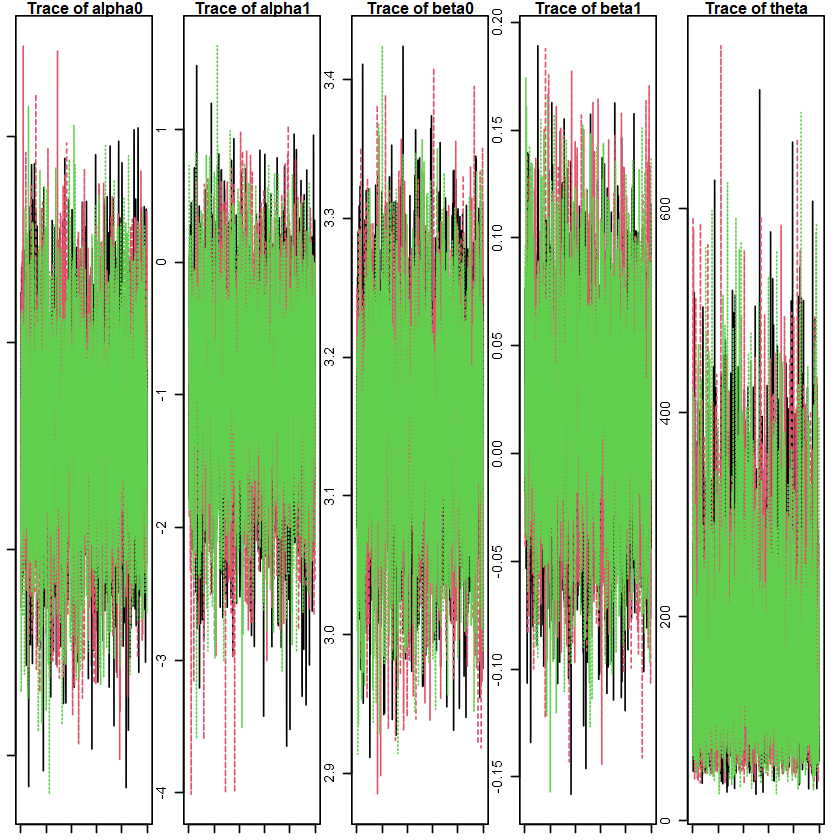

[1] "Pessimistic"


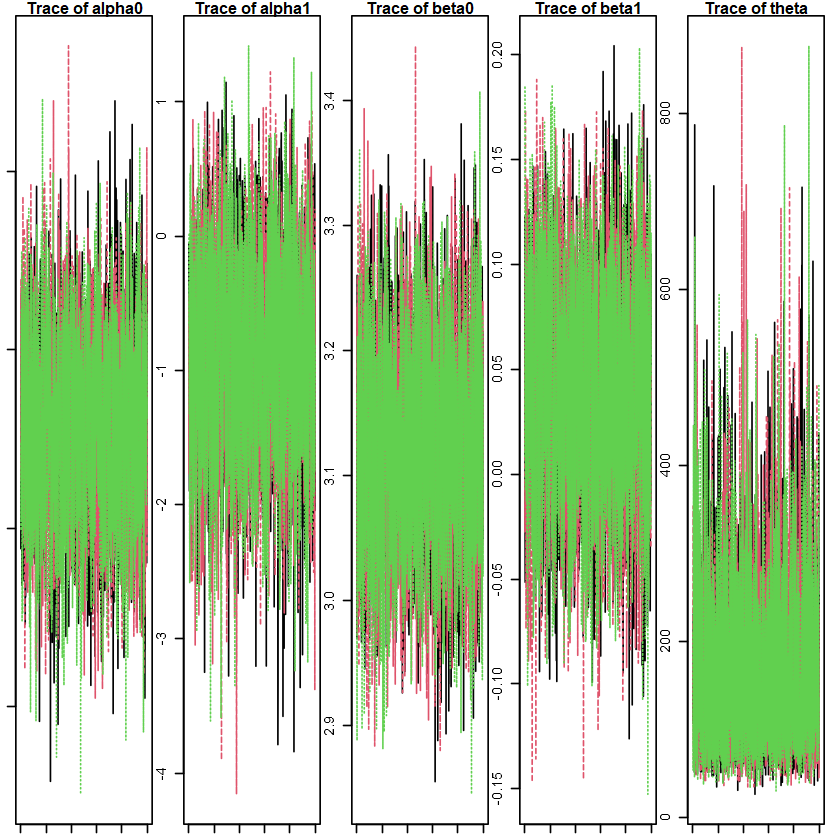

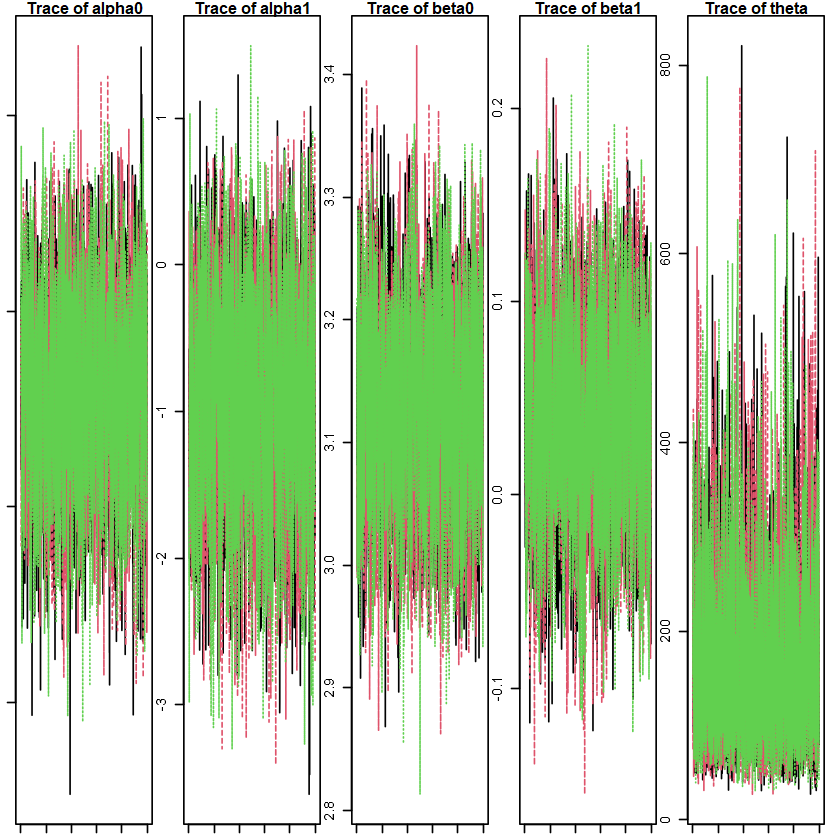

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "traceplot")
print("Optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "traceplot")
print("Pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "traceplot")


par(mfrow = c(1,1))


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "gelman")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "gelman")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "gelman")

[1] "Non informative"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1          1
alpha1          1          1
beta0           1          1
beta1           1          1
theta           1          1

Multivariate psrf

1

[1] "Optimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1          1
alpha1          1          1
beta0           1          1
beta1           1          1
theta           1          1

Multivariate psrf

1

[1] "Pessimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1       1.00
alpha1          1       1.00
beta0           1       1.00
beta1           1       1.00
theta           1       1.01

Multivariate psrf

1

In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "autocorr")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "autocorr")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "autocorr")

[1] "Non informative"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.0000000000,1.0000000000,1.000000000
Lag 15,0.315620786,0.313750538,0.3772994473,0.3761869743,0.021612439
Lag 75,-0.010620270,-0.004975580,-0.0006207868,-0.0009872664,-0.009304908
Lag 150,-0.051520449,-0.034610633,0.0018494782,0.0021534908,-0.003930695
Lag 750,-0.007022231,-0.002638177,-0.0003298007,-0.0014928470,-0.004606840


[1] "Optimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.00000000,1.00000000,1.0000000000,1.000000000,1.000000000
Lag 15,0.31622593,0.31180354,0.3530181621,0.360721950,0.008751104
Lag 75,0.02098291,0.01640553,-0.0085901328,-0.005619162,-0.002397877
Lag 150,-0.01597272,-0.01085712,-0.0219414758,-0.022332140,0.007928779
Lag 750,0.02667723,0.02246763,-0.0007994542,0.000903986,-0.009170326


[1] "Pessimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.00000000,1.00000000,1.000000000,1.00000000,1.000000000
Lag 15,0.29392900,0.29958536,0.364901980,0.37398835,-0.002766653
Lag 75,-0.01611345,-0.01762219,0.001031169,-0.01004150,-0.022534892
Lag 150,0.01127510,0.01001552,0.017429654,0.02617756,0.005217307
Lag 750,0.01983380,0.01346658,0.013065232,0.01719298,0.009871999


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "effectivesize")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "effectivesize")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "effectivesize")

[1] "Non informative"


alpha0   alpha1    beta0    beta1    theta 
2600.244 2891.360 1991.210 2096.565 4891.813

[1] "Optimistic"


alpha0   alpha1    beta0    beta1    theta 
2573.070 2542.917 2572.606 2440.648 4586.559

[1] "Pessimistic"


alpha0   alpha1    beta0    beta1    theta 
2727.619 2857.740 2546.735 2277.383 4901.612

[1] "Non informative"
[1] "optimistic"


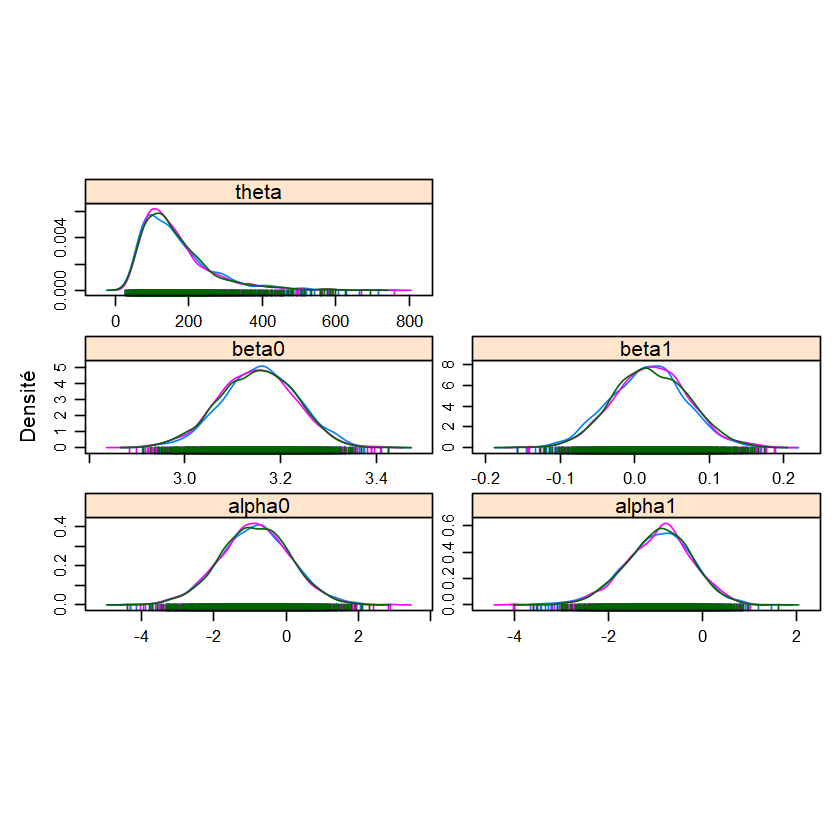

[1] "pessimistic"


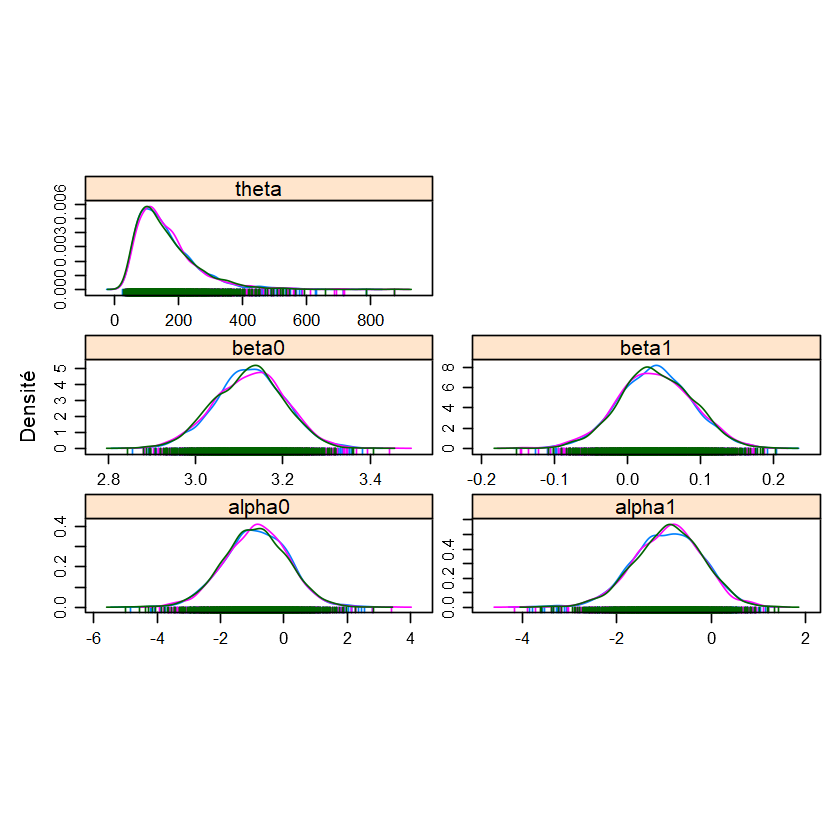

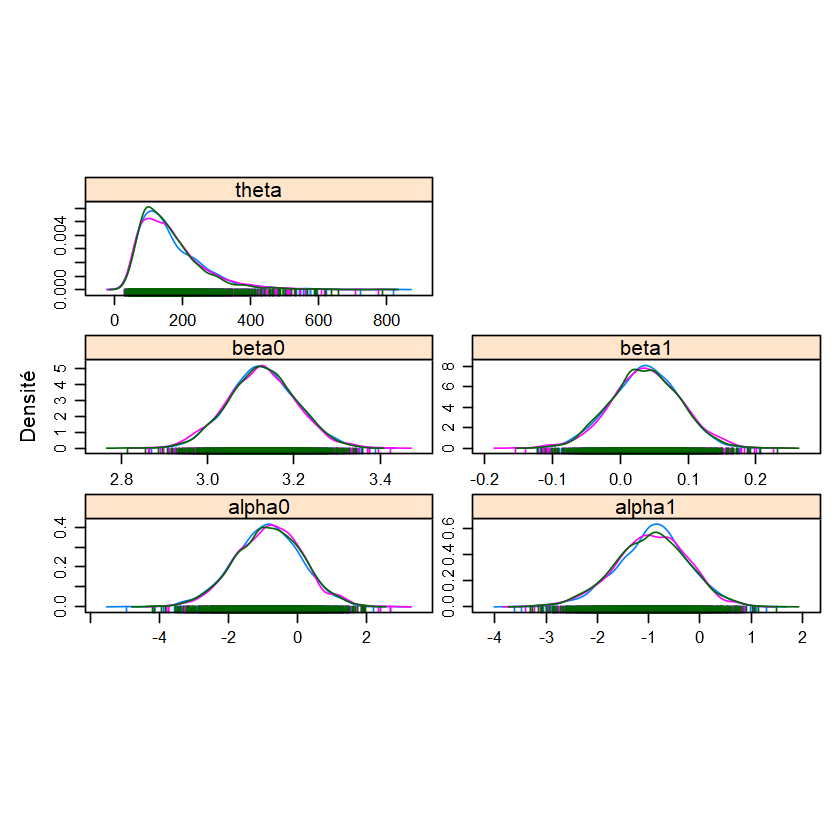

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "density")
print("optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "density")
print("pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "density")


par(mfrow = c(1,1))


In [ ]:
lik_zinb<-rowSums(as.matrix(bmod_zinb$likelihood(model = mod_zinb,  likelihood_name="loglik", niter = 25000, thin = 15) ))

lik_zinb_op<-rowSums(as.matrix(bmod_zinb_op$likelihood(model = mod_zinb_op,  likelihood_name="loglik", niter = 25000, thin = 15)))

lik_zinb_pess<-rowSums(as.matrix(bmod_zinb_pess$likelihood(model = mod_zinb_pess,  likelihood_name="loglik", niter = 25000, thin = 15)))


In [ ]:
scale_minmax <- function(x) (x - min(x,na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))

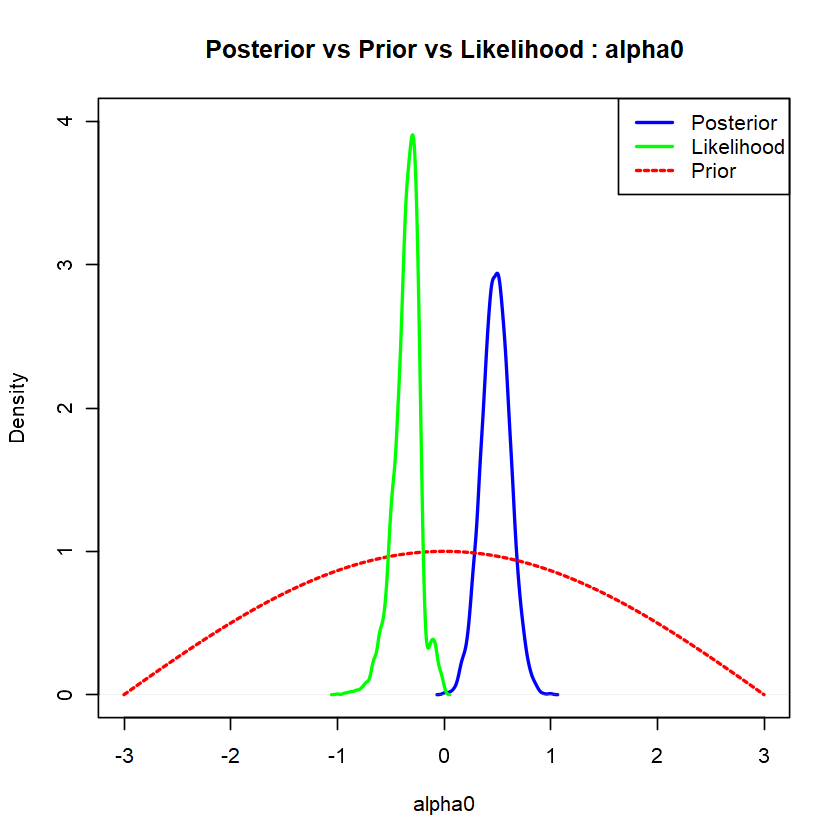

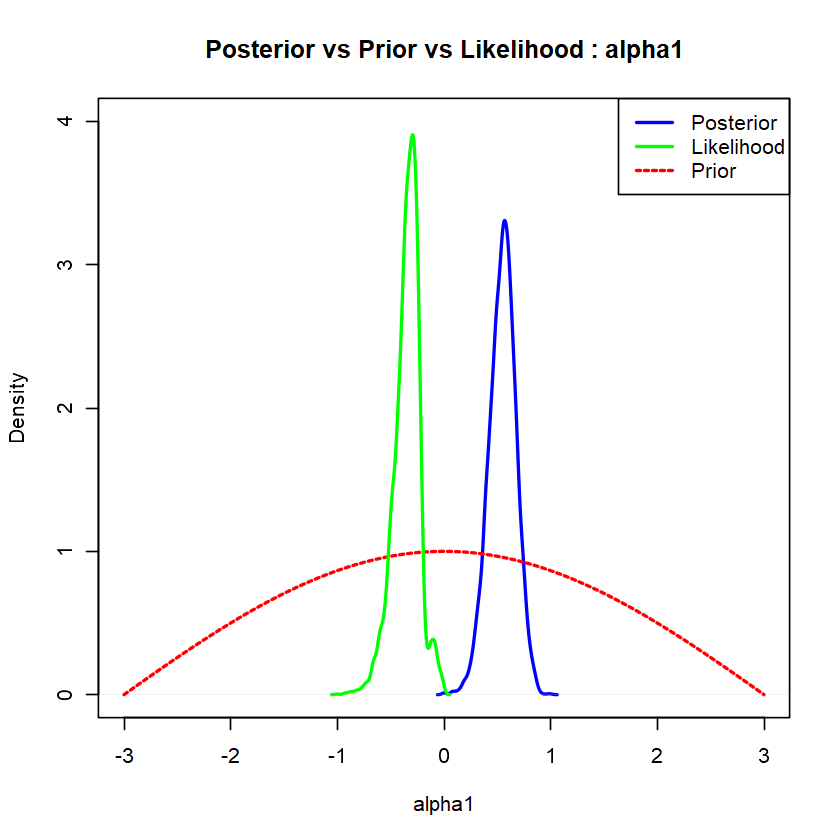

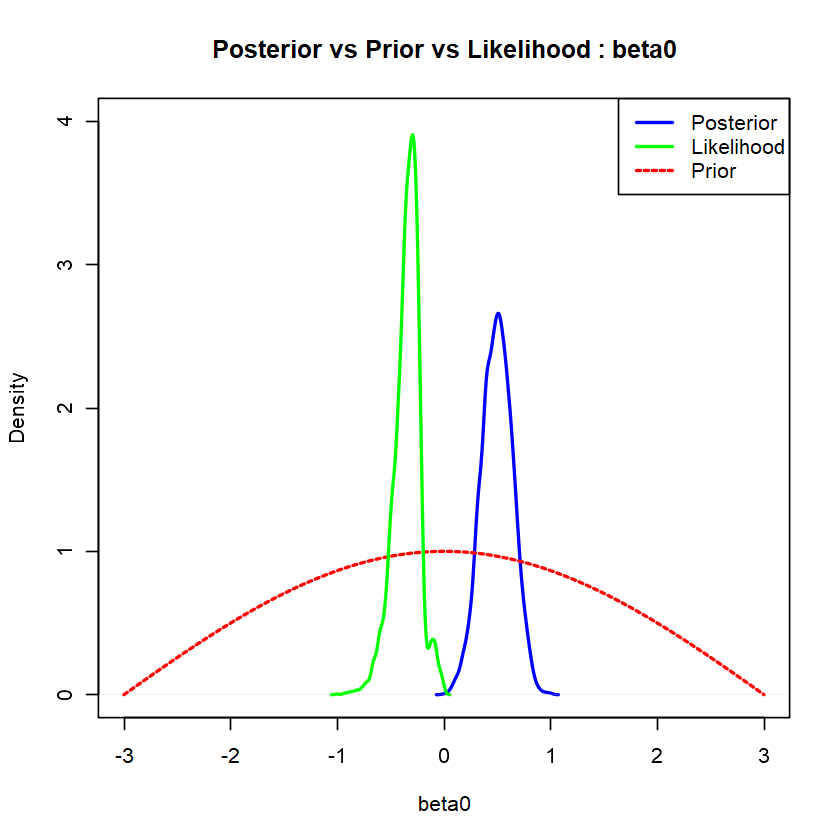

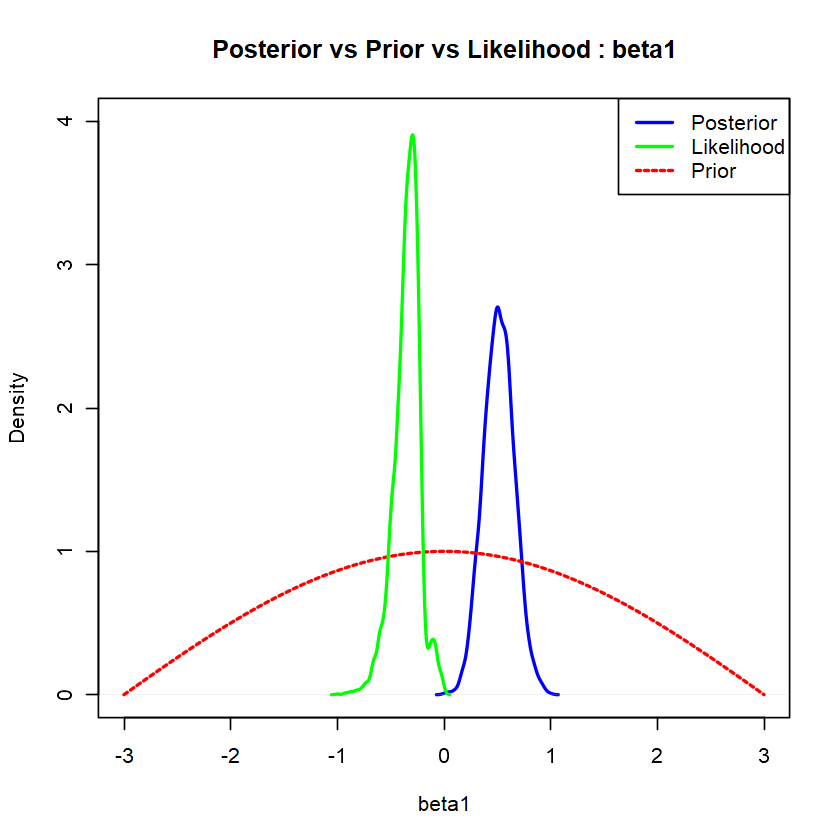

In [ ]:
bmod_zinb$graphs(sample=apply(as.matrix(samp_zinb), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb-max(lik_zinb))/(max(lik_zinb)-min(lik_zinb)),
                ylim=c(0,4),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10))))
                        )
                        )


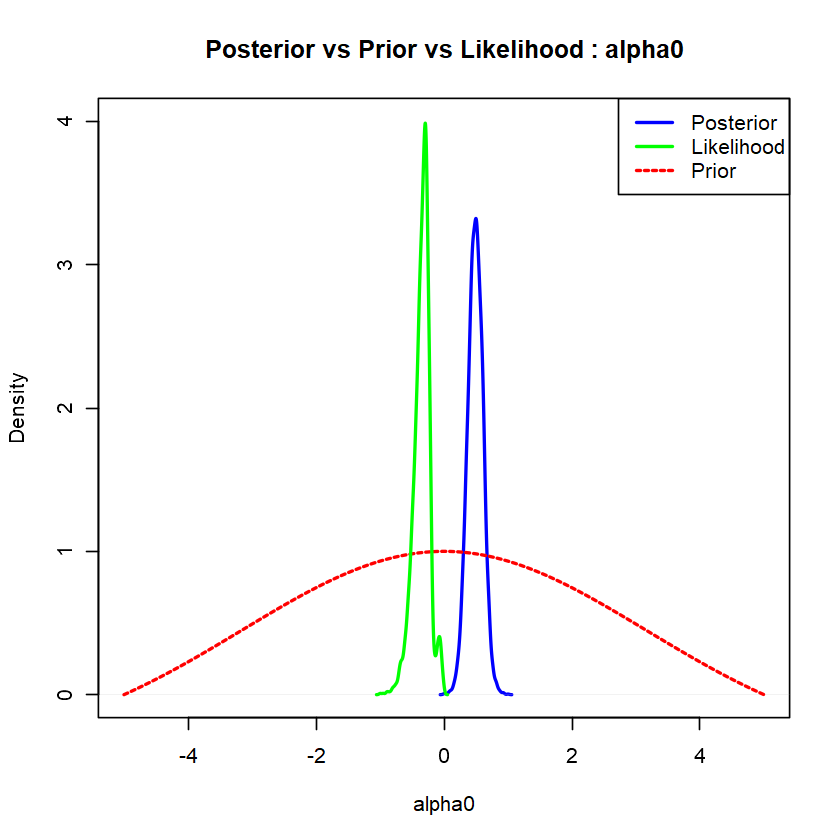

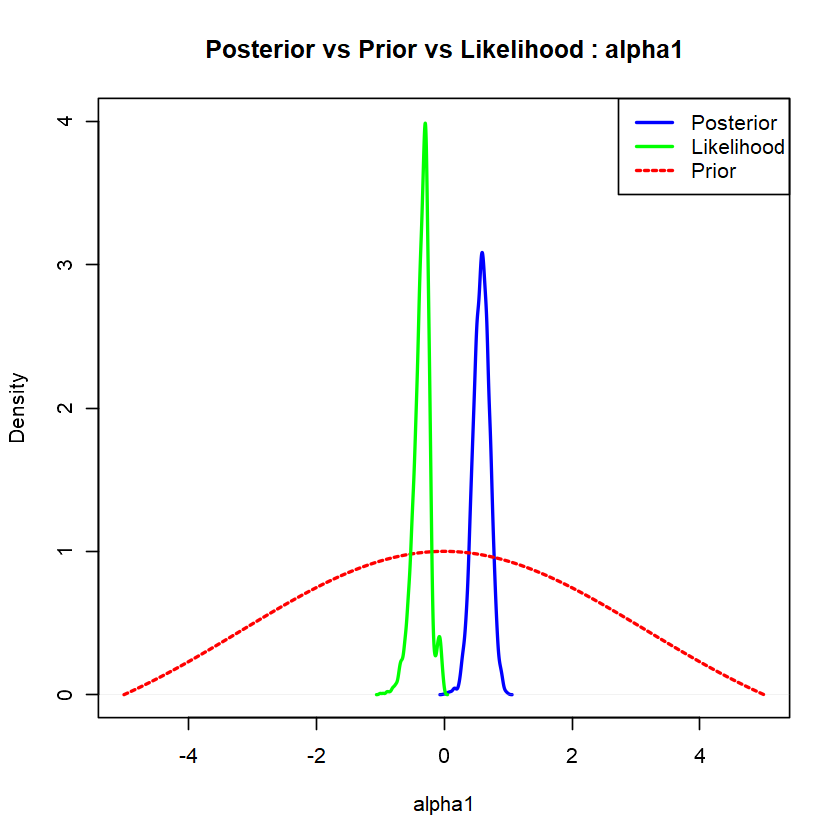

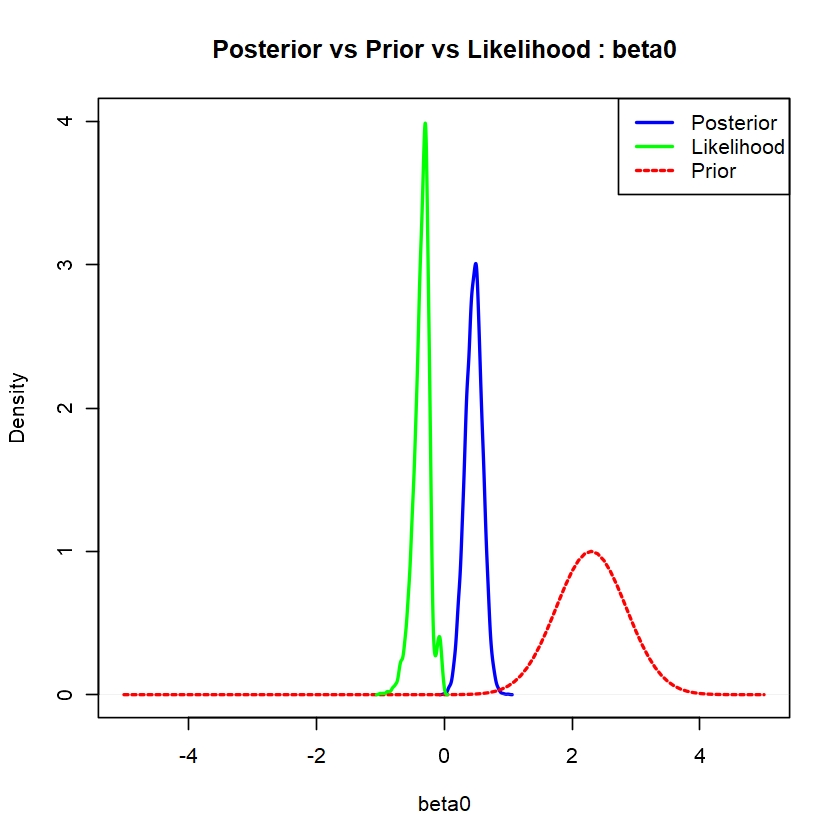

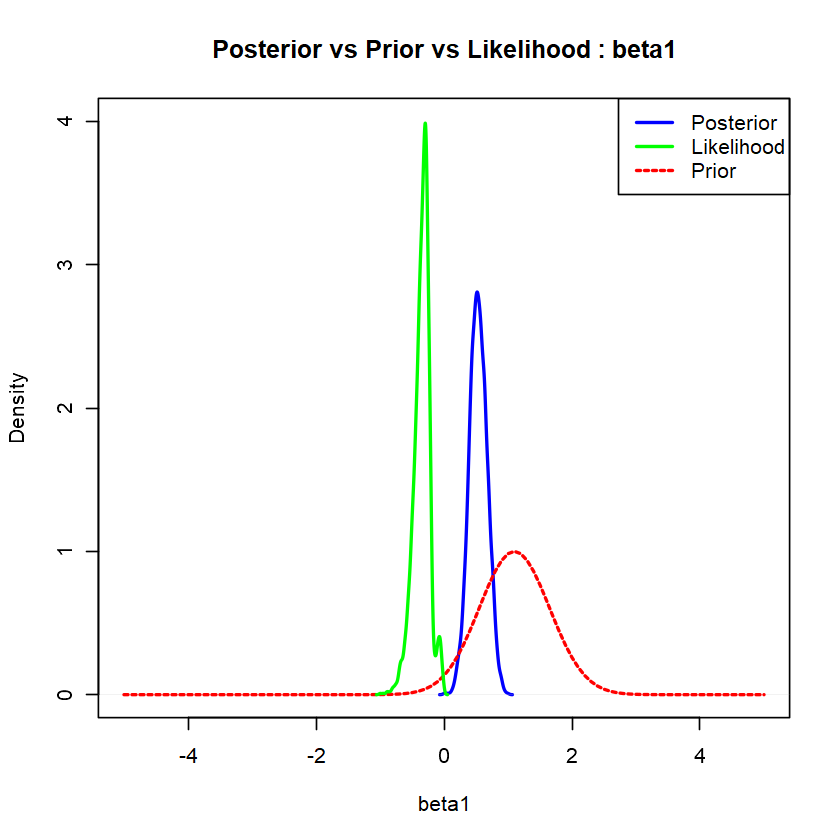

In [ ]:
bmod_zinb_op$graphs(sample=apply(as.matrix(samp_zinb_op), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb_op-max(lik_zinb_op))/(max(lik_zinb_op)-min(lik_zinb_op)),
                ylim=c(0,4),
                xlim=c(-5,5),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 2.3, sd = sqrt(0.3)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 1.1, sd = sqrt(0.3))))
                        )
                        )



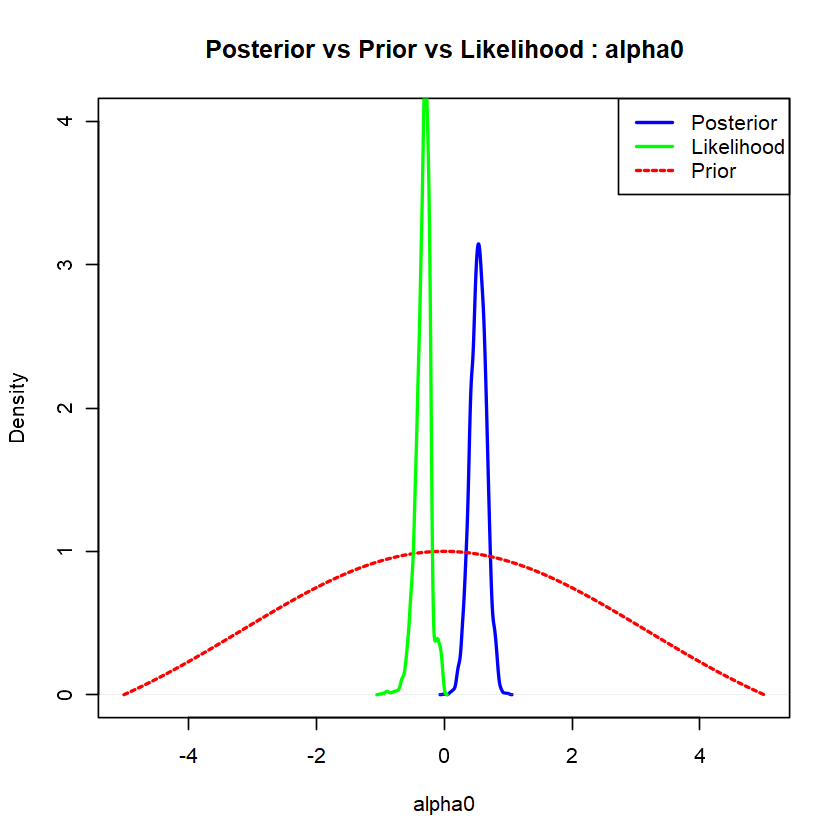

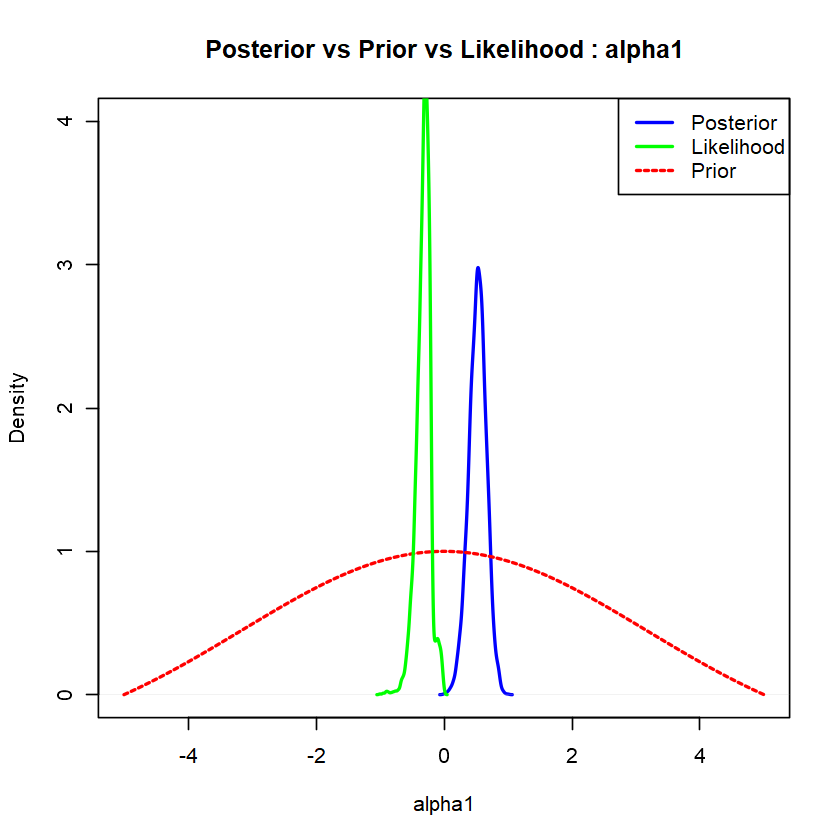

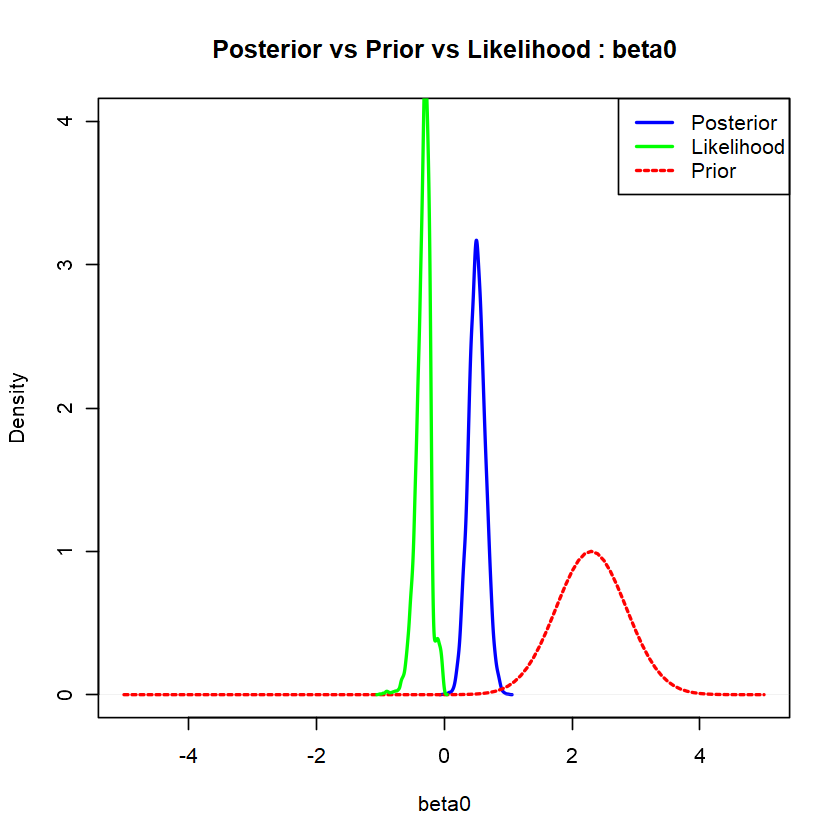

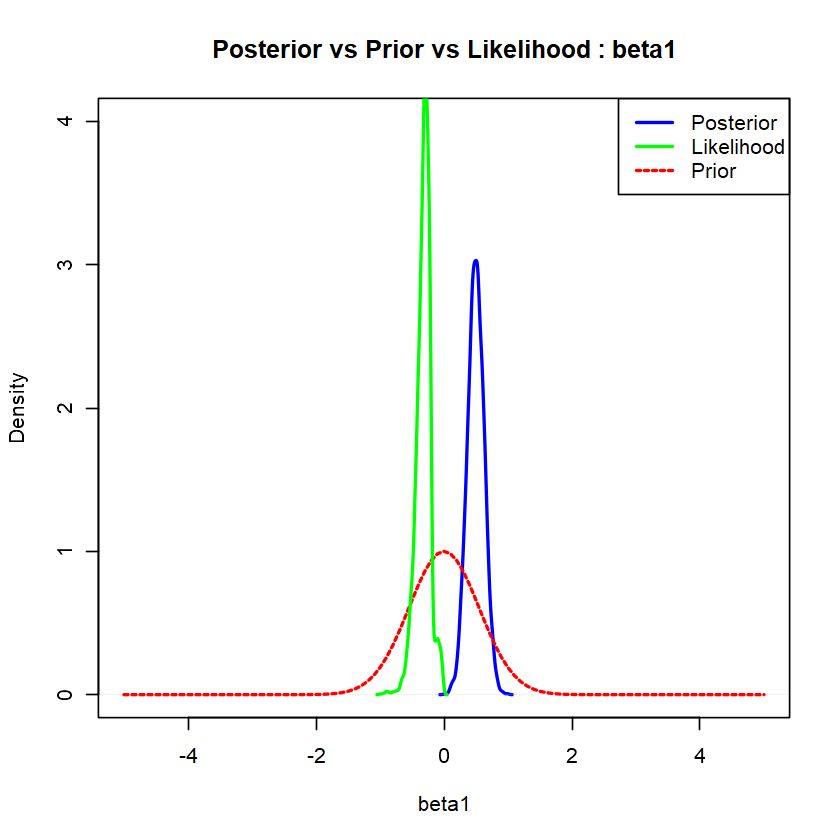

In [ ]:
bmod_zinb_pess$graphs(sample=apply(as.matrix(samp_zinb_pess), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb_pess-max(lik_zinb_pess))/(max(lik_zinb_pess)-min(lik_zinb_pess)),
                ylim=c(0,4),
                xlim=c(-5,5),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 2.3, sd = sqrt(0.3)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(0.3))))
                        )
                        )


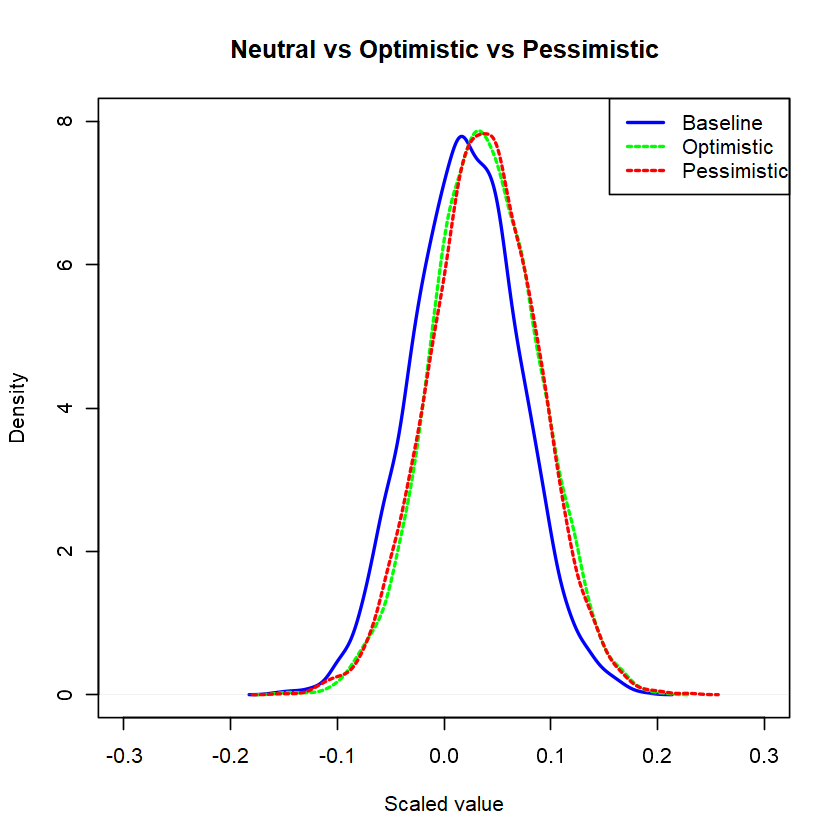

In [ ]:
# # Convert to numeric vectors
# lik_base <- as.numeric(lik_zinb)
# lik_op   <- as.numeric(lik_zinb_op)
# lik_pess <- as.numeric(lik_zinb_pess)

# # Min-max scale each to [0,1] for plotting

# # lik_base_s <- scale_minmax(lik_base)
# # lik_op_s   <- scale_minmax(lik_op)
# # lik_pess_s <- scale_minmax(lik_pess)

# Example: plot as densities
plot(density(as.matrix(samp_zinb)[, "beta1"]), col = "blue", lwd = 2, main = "Neutral vs Optimistic vs Pessimistic", xlab = "Scaled value",xlim=c(-0.3,0.3), ylim=c(0,8))
lines(density(as.matrix(samp_zinb_op)[, "beta1"]), col = "green", lwd = 2, lty = 2)
lines(density(as.matrix(samp_zinb_pess)[, "beta1"]), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Baseline", "Optimistic", "Pessimistic"),
       col = c("blue","green","red"), lwd = 2, lty = c(1,2,2))


Let's add a vector of covariate $W \in\mathbb{R}^p$, considering a sample $(x,y,z,w)=((x_1,y_1,z_1,w_1),..., (x_n,y_n,z_n,w_1))$, we have:
$$
\psi(\alpha,\beta,\zeta,\delta,\eta,\mu,\nu,\theta/y)\approx \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} \frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\Biggl [ \gamma(x,w) \mathbf{1}_{y=0}+ (1-\gamma(x,w))\binom{y+\theta-1}{y}p(x)^{\theta}(1-p(x))^y \Biggr]
$$
where :
- $\gamma(x,w)= P(Z=1/X=x, W=w) = \frac{\exp(\alpha_0 + \alpha_1 x + \eta^\top w + \zeta^\top (xw))}{1+\exp(\alpha_0 + \alpha_1 x + \eta^\top w + \zeta^\top (xw))}$
- $E(Y)=\Mu(x,w) = \theta\frac{1-p(x)}{p(x)}$ with $\Mu(x,w)=\exp(\beta_0 + \beta_1 x + \delta^\top w + \nu^\top (xw))$, so $p(x)=\frac{\theta}{\exp(\beta_0 + \beta_1 x + \delta^\top w + \nu^\top (xw)) + \theta}$
- $w, \eta, \zeta, \delta, \nu \in \mathbb{R}^p$


